## 🔧 Configuração inicial

### Instalação das bibliotecas

Execute a célula abaixo **uma única vez** para instalar todas as bibliotecas utilizadas neste notebook. Caso já as tenha instaladas em seu ambiente, você pode pular esta etapa.

In [142]:
# Instalação das bibliotecas necessárias (execute apenas uma vez)
%pip install pandas numpy matplotlib seaborn scipy scikit-learn imbalanced-learn -q

Note: you may need to restart the kernel to use updated packages.


Agora vamos importar as bibliotecas que utilizaremos ao longo de todo o notebook.

In [143]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Machine Learning (pré-processamento e seleção de features)
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler
)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
# 📁 Módulo 2 — Carregamento e Exploração de Dados CSV

Nesta seção, carregamos o arquivo CSV e realizamos a primeira exploração do conjunto de dados: dimensões, colunas, tipos, estatísticas descritivas e cardinalidade.

In [144]:
# Carregamento do dataset
dataframe = pd.read_csv("./data/all_spectra_combined.csv", sep=",", encoding="utf-8")

print(f"O dataset foi carregado com sucesso!")
print(f"Dimensões: {dataframe.shape[0]} linhas x {dataframe.shape[1]} colunas")

O dataset foi carregado com sucesso!
Dimensões: 3736 linhas x 36 colunas


### 2.1 Primeira inspeção visual

In [145]:
dataframe.head()

,wavenumber,M1_1,M1_2,M1_3,M1_4,M1_5,M1_6,M1_7,M1_8,M1_9,M1_10,M1_11,M1_12,M2_1,M2_2,M2_3,M2_4,M2_5,M2_6,M2_7,M2_8,M2_9,M2_10,M2_11,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
0,399.192657,-0.092334,-0.135155,-0.116006,-0.092241,-0.095453,-0.107408,-0.132602,-0.116408,-0.109174,-0.109282,-0.131137,-0.106476,0.008819,-0.120327,-0.000220,-0.133132,-0.125215,-0.130598,-0.136143,-0.126056,-0.136734,-0.084545,-0.116989,-0.138569,-0.144169,-0.104311,-0.124477,-0.111986,-0.114944,-0.083600,-0.106035,-0.112652,-0.115926,-0.074283,-0.130334
1,400.156891,-0.094457,-0.134812,-0.117210,-0.093534,-0.097804,-0.107151,-0.132074,-0.116168,-0.109993,-0.110899,-0.130374,-0.107729,0.007540,-0.120158,0.000667,-0.132673,-0.123911,-0.130470,-0.136182,-0.123301,-0.136621,-0.086543,-0.117716,-0.136068,-0.142956,-0.106225,-0.124513,-0.111383,-0.115328,-0.084596,-0.105617,-0.112467,-0.115366,-0.078355,-0.130413
2,401.121124,-0.096179,-0.135385,-0.118377,-0.094566,-0.100259,-0.107841,-0.132476,-0.116420,-0.111798,-0.112751,-0.128085,-0.109363,0.005838,-0.120079,0.001008,-0.131376,-0.122598,-0.129053,-0.134978,-0.121291,-0.136004,-0.089422,-0.118164,-0.135142,-0.143007,-0.106881,-0.124206,-0.110736,-0.115958,-0.085112,-0.105785,-0.112037,-0.114389,-0.083119,-0.130307
3,402.085358,-0.097254,-0.136129,-0.119083,-0.095578,-0.102493,-0.109283,-0.133601,-0.117182,-0.114043,-0.114636,-0.124963,-0.111086,0.004146,-0.120060,0.000763,-0.129706,-0.121551,-0.127202,-0.133208,-0.120015,-0.135230,-0.092020,-0.118549,-0.135705,-0.143825,-0.106631,-0.123745,-0.110316,-0.116469,-0.085296,-0.106135,-0.111573,-0.113420,-0.087632,-0.130177
4,403.049591,-0.097691,-0.136643,-0.119237,-0.096713,-0.104471,-0.111068,-0.135178,-0.118349,-0.116211,-0.116346,-0.121742,-0.112628,0.002736,-0.120100,0.000057,-0.127909,-0.120710,-0.125645,-0.131436,-0.119277,-0.134619,-0.093757,-0.118894,-0.137108,-0.144989,-0.105908,-0.123309,-0.110174,-0.116909,-0.085219,-0.106542,-0.111178,-0.112668,-0.091403,-0.130125


In [146]:
dataframe.tail()

,wavenumber,M1_1,M1_2,M1_3,M1_4,M1_5,M1_6,M1_7,M1_8,M1_9,M1_10,M1_11,M1_12,M2_1,M2_2,M2_3,M2_4,M2_5,M2_6,M2_7,M2_8,M2_9,M2_10,M2_11,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
3731,3996.747739,0.009670,0.027798,0.028145,-0.002175,0.018460,0.030759,0.083337,0.013059,0.018038,0.038942,0.022040,0.025281,0.000444,0.040550,-0.011405,0.021376,0.018767,0.021182,0.032693,0.014876,0.040195,0.046498,0.028391,0.064571,0.102503,0.032454,0.030460,0.013576,0.029479,-0.008252,-0.006527,0.015907,0.026169,0.002954,0.072197
3732,3997.711973,0.009706,0.027801,0.028243,-0.002123,0.018455,0.030776,0.083561,0.012956,0.018015,0.038869,0.022160,0.025196,0.000547,0.040543,-0.011376,0.021436,0.018897,0.021356,0.032739,0.014997,0.040318,0.046448,0.028461,0.064681,0.102354,0.032459,0.030424,0.013613,0.029502,-0.008235,-0.006636,0.015979,0.026133,0.002856,0.072218
3733,3998.676206,0.009757,0.027729,0.028209,-0.001993,0.018412,0.030797,0.083797,0.012758,0.018011,0.038820,0.022233,0.025119,0.000643,0.040510,-0.011295,0.021468,0.018959,0.021562,0.032741,0.015214,0.040516,0.046469,0.028536,0.064852,0.102214,0.032404,0.030307,0.013593,0.029551,-0.008248,-0.006779,0.016015,0.026023,0.002683,0.072200
3734,3999.640439,0.009813,0.027665,0.028076,-0.001867,0.018331,0.030832,0.083990,0.012501,0.018003,0.038773,0.022231,0.025056,0.000717,0.040444,-0.011176,0.021442,0.018951,0.021726,0.032698,0.015422,0.040731,0.046562,0.028571,0.065048,0.102144,0.032314,0.030138,0.013524,0.029598,-0.008272,-0.006876,0.016041,0.025853,0.002497,0.072196
3735,4000.604673,0.009995,0.027689,0.027654,-0.001814,0.018376,0.030849,0.083820,0.012441,0.017704,0.038781,0.022079,0.024939,0.000924,0.040585,-0.010906,0.021443,0.018967,0.021974,0.032646,0.015352,0.040710,0.046452,0.028641,0.065370,0.102543,0.032406,0.030242,0.013622,0.029894,-0.008259,-0.006799,0.016019,0.025743,0.002547,0.072472


### 2.2 Dimensões, colunas e tipos de dados

In [147]:
print("Formato (linhas, colunas):", dataframe.shape)
print("\nNomes das colunas:")
print(dataframe.columns.tolist())
print("\nNomes das colunas:")

Formato (linhas, colunas): (3736, 36)

Nomes das colunas:
['wavenumber', 'M1_1', 'M1_2', 'M1_3', 'M1_4', 'M1_5', 'M1_6', 'M1_7', 'M1_8', 'M1_9', 'M1_10', 'M1_11', 'M1_12', 'M2_1', 'M2_2', 'M2_3', 'M2_4', 'M2_5', 'M2_6', 'M2_7', 'M2_8', 'M2_9', 'M2_10', 'M2_11', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12']

Nomes das colunas:


Isso aqui informa os dados de cada coluna, nesse caso são 36 delas, todas completamente preenchidas com dados do tipo float64.

In [148]:
# Isso aqui informa os dados de cada coluna, nesse caso são 36 delas
# todas completamente preenchidas com dados do tipo float64
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 3736 entries, 0 to 3735
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   wavenumber  3736 non-null   float64
 1   M1_1        3736 non-null   float64
 2   M1_2        3736 non-null   float64
 3   M1_3        3736 non-null   float64
 4   M1_4        3736 non-null   float64
 5   M1_5        3736 non-null   float64
 6   M1_6        3736 non-null   float64
 7   M1_7        3736 non-null   float64
 8   M1_8        3736 non-null   float64
 9   M1_9        3736 non-null   float64
 10  M1_10       3736 non-null   float64
 11  M1_11       3736 non-null   float64
 12  M1_12       3736 non-null   float64
 13  M2_1        3736 non-null   float64
 14  M2_2        3736 non-null   float64
 15  M2_3        3736 non-null   float64
 16  M2_4        3736 non-null   float64
 17  M2_5        3736 non-null   float64
 18  M2_6        3736 non-null   float64
 19  M2_7        3736 non-null   float64
 2

In [149]:
# pegando os datatype do frame e contando os valores, nesse caso tem 36 float64
dataframe.dtypes.value_counts()

float64    36
Name: count, dtype: int64

### 2.3 Estatísticas descritivas

`dataframe.describe()` resume as variáveis **numéricas**. Para incluir também as **categóricas**, usamos `include="all"`.

In [150]:
# como nessa base só tem numéricas, já funciona só assim
dataframe.describe()

,wavenumber,M1_1,M1_2,M1_3,M1_4,M1_5,M1_6,M1_7,M1_8,M1_9,M1_10,M1_11,M1_12,M2_1,M2_2,M2_3,M2_4,M2_5,M2_6,M2_7,M2_8,M2_9,M2_10,M2_11,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12
count,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000,3736.000000
mean,2199.898665,0.008133,0.030800,0.036991,0.008898,0.030913,0.032737,0.063304,0.026007,0.023624,0.039673,0.027259,0.036493,-0.000338,0.036112,-0.012695,0.027981,0.028754,0.028860,0.032127,0.019929,0.042790,0.052827,0.032025,0.044894,0.069758,0.035935,0.032067,0.026751,0.039200,-0.001083,0.004920,0.022975,0.029289,0.018586,0.063414
std,1040.055614,0.043144,0.060212,0.047622,0.047329,0.062186,0.061894,0.091406,0.060412,0.043519,0.061805,0.052096,0.055242,0.024689,0.066551,0.029714,0.046690,0.055364,0.059672,0.061438,0.046893,0.065440,0.044392,0.046361,0.071022,0.088778,0.060290,0.061893,0.048827,0.070924,0.030610,0.048656,0.052152,0.057101,0.048452,0.072736
min,399.192657,-0.099362,-0.136756,-0.121211,-0.108806,-0.114968,-0.116686,-0.148436,-0.122060,-0.118674,-0.119356,-0.131137,-0.117031,-0.066896,-0.125028,-0.097109,-0.133132,-0.125215,-0.130598,-0.136182,-0.126056,-0.136734,-0.098574,-0.122863,-0.140347,-0.149802,-0.109640,-0.126289,-0.117257,-0.125808,-0.085296,-0.115579,-0.112652,-0.116516,-0.098562,-0.136531
25%,1299.545661,-0.005187,0.009589,0.019906,-0.010671,0.001754,0.009043,0.030576,-0.001065,0.009629,0.015978,0.007303,0.013928,-0.006944,0.012032,-0.022341,0.012148,0.005679,0.004615,0.012116,0.000112,0.019127,0.038728,0.018491,0.029090,0.048139,0.011056,0.008051,0.005075,0.008693,-0.010673,-0.013532,0.002233,0.007667,-0.002906,0.041393
50%,2199.898665,0.016711,0.049690,0.057131,0.023393,0.057035,0.054279,0.089317,0.049265,0.043003,0.062805,0.050087,0.060863,-0.000525,0.052716,-0.010168,0.048001,0.052968,0.047352,0.050037,0.040958,0.066586,0.062393,0.049693,0.070097,0.097509,0.050756,0.051369,0.049819,0.060780,0.006175,0.013661,0.044225,0.044633,0.037905,0.084288
75%,3100.251669,0.036943,0.068341,0.065442,0.041357,0.071027,0.069986,0.118020,0.065124,0.049129,0.077771,0.058966,0.071302,0.009584,0.077186,0.000697,0.056381,0.063188,0.067675,0.069892,0.051297,0.083080,0.078075,0.059526,0.086463,0.122645,0.073697,0.070896,0.057967,0.084499,0.020286,0.040094,0.055820,0.066072,0.051848,0.104457
max,4000.604673,0.103735,0.148568,0.104478,0.107595,0.155477,0.159414,0.245511,0.142104,0.083465,0.160515,0.113005,0.128087,0.093460,0.175558,0.082214,0.087557,0.128353,0.146170,0.159127,0.084896,0.162852,0.139890,0.095387,0.160071,0.229110,0.164622,0.147279,0.096969,0.184143,0.063786,0.114483,0.121237,0.146142,0.103446,0.200502


In [151]:
# o T se faz a matriz ser transversal
dataframe.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
wavenumber,3736.0,2199.898665,1040.055614,399.192657,1299.545661,2199.898665,3100.251669,4000.604673
M1_1,3736.0,0.008133,0.043144,-0.099362,-0.005187,0.016711,0.036943,0.103735
M1_2,3736.0,0.030800,0.060212,-0.136756,0.009589,0.049690,0.068341,0.148568
M1_3,3736.0,0.036991,0.047622,-0.121211,0.019906,0.057131,0.065442,0.104478
M1_4,3736.0,0.008898,0.047329,-0.108806,-0.010671,0.023393,0.041357,0.107595
M1_5,3736.0,0.030913,0.062186,-0.114968,0.001754,0.057035,0.071027,0.155477
M1_6,3736.0,0.032737,0.061894,-0.116686,0.009043,0.054279,0.069986,0.159414
M1_7,3736.0,0.063304,0.091406,-0.148436,0.030576,0.089317,0.118020,0.245511
M1_8,3736.0,0.026007,0.060412,-0.122060,-0.001065,0.049265,0.065124,0.142104
M1_9,3736.0,0.023624,0.043519,-0.118674,0.009629,0.043003,0.049129,0.083465


### 2.4 Cardinalidade e distribuição de classes

A cardinalidade indica quantos valores únicos existem em cada coluna — importante para decidir estratégias de codificação (Módulo 5).

Fazendo a análise dos valores, dá pra ver que a enorme maioria são únicos, com um máximo de 3 repetidos por linha. Conferir esses poucos valores em passos futuros.

In [152]:
cardinalidade = dataframe.nunique().sort_values(ascending=False)
cardinalidade

wavenumber    3736
M1_1          3736
M1_2          3736
M1_4          3736
PC_11         3736
M1_5          3736
M1_6          3736
M1_7          3736
M1_8          3736
M1_9          3736
M1_10         3736
M1_12         3736
M2_4          3736
M2_2          3736
PC_8          3736
PC_3          3736
PC_4          3736
M2_11         3736
M2_10         3736
M2_8          3736
PC_7          3736
PC_9          3736
PC_5          3736
M1_3          3735
M2_1          3735
M1_11         3735
M2_5          3735
M2_3          3735
PC_1          3735
M2_6          3735
M2_9          3735
PC_2          3735
PC_10         3735
M2_7          3734
PC_6          3734
PC_12         3734
dtype: int64

In [153]:
# Distribuição de uma variável de interesse
dataframe["PC_6"].value_counts()

PC_6
 0.065054    2
 0.064891    2
-0.114944    1
-0.115328    1
-0.115958    1
            ..
 0.029479    1
 0.029502    1
 0.029551    1
 0.029598    1
 0.029894    1
Name: count, Length: 3734, dtype: int64

Dois valores repetidos, "0.065054" e "0.064891", e todo o resto único

---
# 🧪 Módulo 3 — Qualidade dos Dados

Vamos investigar valores ausentes, duplicados e outros problemas comuns de qualidade.

### 3.1 Valores ausentes

Felizmente, nessa base não há nenhum valor ausente, então essa etapa podem ser ignorada.

### 3.2 Dados duplicados

In [154]:
duplicados = dataframe.duplicated().sum()
print(f"Número de linhas totalmente duplicadas: {duplicados}")

duplicados_sem_wavenumber = dataframe.drop(columns=["wavenumber"]).duplicated().sum()
print(f"Número de linhas duplicadas (ignorando o wavenumber): {duplicados_sem_wavenumber}")

Número de linhas totalmente duplicadas: 0
Número de linhas duplicadas (ignorando o wavenumber): 0


### 3.3 Valores inválidos / fora do domínio esperado

Uma boa prática é verificar se variáveis numéricas possuem valores fisicamente impossíveis (ex.: área negativa, ano de construção no futuro).

Fazendo a análise dos dados de cada coluna, foi observado com comportamento recorrente: os números se mantém próximos dos valores -0,15 e 0,25. Considerando a natureza do que foi analisado e salvo na base, o domínio aceito para dados foi "Números reais próximos à -0,15 e 0,25", padrão que todas as amostras seguem até o momento.

In [155]:
dataframe['M2_8'].describe()

count    3736.000000
mean        0.019929
std         0.046893
min        -0.126056
25%         0.000112
50%         0.040958
75%         0.051297
max         0.084896
Name: M2_8, dtype: float64

### 3.4 Tipos incorretos

Todas as variáveis são do tipo float64, então essa etapa pode ser ignorada.

### 3.5 Tratamento inicial de valores ausentes (exemplo)

Felizmente, nessa base não há nenhum valor ausente, então essa etapa podem ser ignorada.

---
# 🧹 Módulo 4 — Limpeza e Padronização de Dados

Nesta seção, tratamos de forma consolidada os principais problemas identificados no Módulo 3, criando uma versão limpa do dataset (`dataframe_limpo`).

In [156]:
dataframe_limpo = dataframe.copy()

### 4.1 Limpeza de strings

A base de dados não possui Strings como campos válidos, esse processo pode ser pulado.

### 4.2 Tratamento de valores ausentes por significado

Toda a tabela está preenchida por valores dentro do universo, nenhum deles é ausente de significado.

### 4.3 Tratamento de valores realmente ausentes

Toda a tabela está preenchida por valores dentro do universo, não há campos ausentes.

### 4.4 Padronização de categorias

A base de dados não possui Strings como campos válidos, esse processo pode ser pulado.

### 4.5 Conversão de tipos

A base de dados não possui Strings como campos válidos, esse processo pode ser pulado.

---
### Como não haviam dados a serem tratados, em grande parte pelo fato de não haverem Strings no banco, mas também por todos os campos estarem devidamente preenchidos, o Módulo 4 foi majoritariamente ignorado. Mesmo assim, seguiremos usando dataframe_limpo daqui em diante, por convensão e boa prática futura.

> ✅ A partir daqui, utilizaremos `dataframe_limpo` como base para os próximos módulos.

---
# 🏷️ Módulo 5 — Variáveis Categóricas

Vamos identificar variáveis nominais e ordinais e aplicar as técnicas de codificação apropriadas para cada uma.

Mais uma vez, a base de dados utiliza não possui variáveis categóricas, as instruções do módulo serão mantidas para referência, mas não utilizadas.

### 5.1 Identificando variáveis nominais e ordinais

### 5.2 Ordinal Encoding

### 5.3 Label Encoding

### 5.4 One-Hot Encoding

### 5.5 Alta cardinalidade

---
# 🔢 Módulo 6 — Variáveis Numéricas

Vamos calcular as principais medidas de tendência central e dispersão para variáveis numéricas relevantes.

In [157]:
variaveis_numericas = [
    "M1_1", "M1_2", "M1_3", "M1_4", "M1_5", "M1_6", "M1_7", "M1_8", "M1_9", "M1_10", "M1_11", "M1_12",
    "M2_1", "M2_2", "M2_3", "M2_4", "M2_5", "M2_6", "M2_7", "M2_8", "M2_9", "M2_10", "M2_11",
    "PC_1", "PC_2", "PC_3", "PC_4", "PC_5", "PC_6", "PC_7", "PC_8", "PC_9", "PC_10", "PC_11", "PC_12",
]

resumo = pd.DataFrame({
    "media": dataframe_limpo[variaveis_numericas].mean(),
    "mediana": dataframe_limpo[variaveis_numericas].median(),
    "moda": dataframe_limpo[variaveis_numericas].mode().iloc[0],
    "variancia": dataframe_limpo[variaveis_numericas].var(),
    "desvio_padrao": dataframe_limpo[variaveis_numericas].std(),
    "amplitude": dataframe_limpo[variaveis_numericas].max() - dataframe_limpo[variaveis_numericas].min(),
})
resumo.round(5)

,media,mediana,moda,variancia,desvio_padrao,amplitude
M1_1,0.00813,0.01671,-0.09936,0.00186,0.04314,0.20310
M1_2,0.03080,0.04969,-0.13676,0.00363,0.06021,0.28532
M1_3,0.03699,0.05713,0.05733,0.00227,0.04762,0.22569
M1_4,0.00890,0.02339,-0.10881,0.00224,0.04733,0.21640
M1_5,0.03091,0.05703,-0.11497,0.00387,0.06219,0.27045
M1_6,0.03274,0.05428,-0.11669,0.00383,0.06189,0.27610
M1_7,0.06330,0.08932,-0.14844,0.00836,0.09141,0.39395
M1_8,0.02601,0.04926,-0.12206,0.00365,0.06041,0.26416
M1_9,0.02362,0.04300,-0.11867,0.00189,0.04352,0.20214
M1_10,0.03967,0.06280,-0.11936,0.00382,0.06180,0.27987


### 6.1 Quartis e percentis

In [158]:
dataframe_limpo["M1_8"].quantile([0.25, 0.5, 0.75])

0.25   -0.001065
0.50    0.049265
0.75    0.065124
Name: M1_8, dtype: float64

In [159]:
# Percentis customizados
dataframe_limpo["M2_8"].quantile([0.05, 0.10, 0.90, 0.95])

0.05   -0.080950
0.10   -0.065121
0.90    0.059736
0.95    0.064317
Name: M2_8, dtype: float64

### 6.2 Discreta vs. contínua

No caso dessa base, todas as variáveis numéricas são contínuas, por poderem assumir qualquer valor real dentro de seus domínios.

In [160]:
print("\nM2_8 (contínua) — min:", dataframe_limpo['M2_8'].min(), "| max:", dataframe_limpo['M2_8'].max())


M2_8 (contínua) — min: -0.1260559856891632 | max: 0.0848959237337112


> 💡 **Interpretação:** compare a média e a mediana de `M2_8` — se forem muito diferentes, isso é um indício de assimetria na distribuição (veremos isso formalmente no Módulo 8).

In [161]:
print("Média de M2_8:", dataframe_limpo["M2_8"].mean().round(5))
print("Mediana de M2_8:", dataframe_limpo["M2_8"].median().round(5))

Média de M2_8: 0.01993
Mediana de M2_8: 0.04096


---
# 📈 Módulo 7 — Outliers

Vamos detectar outliers base de dados usando os métodos IQR e Z-score, e discutir estratégias de tratamento. Esses outliers serão encontrados por meio da análise de cada uma das linhas e seus dados principais, contidos na variável `resumo`, e encontrando aquelas que estão fora do esperado.

### 7.1 Inserção de dados no resumo
Há uma adição rápida que deve ser feita em `resumo` para facilitar a análise dos dados, um campo para qual "grupo" a variável faz parte. Isso ajuda na interpretação por nos possibilitar agrupar cada linha dentro das categorias definidas pela própria base, M1, M2 e PC.

Além disso, definiremos quais métricas vamos usar para encontrar os outliers da base, já que nem todos os campos são exatamente úteis para tal.

In [162]:
metricas = ["media", "mediana", "desvio_padrao", "amplitude"]

resumo["grupo"] = resumo.index.str.split("_").str[0]
resumo

,media,mediana,moda,variancia,desvio_padrao,amplitude,grupo
M1_1,0.008133,0.016711,-0.099362,0.001861,0.043144,0.203098,M1
M1_2,0.030800,0.049690,-0.136756,0.003625,0.060212,0.285324,M1
M1_3,0.036991,0.057131,0.057333,0.002268,0.047622,0.225688,M1
M1_4,0.008898,0.023393,-0.108806,0.002240,0.047329,0.216401,M1
M1_5,0.030913,0.057035,-0.114968,0.003867,0.062186,0.270445,M1
M1_6,0.032737,0.054279,-0.116686,0.003831,0.061894,0.276100,M1
M1_7,0.063304,0.089317,-0.148436,0.008355,0.091406,0.393947,M1
M1_8,0.026007,0.049265,-0.122060,0.003650,0.060412,0.264164,M1
M1_9,0.023624,0.043003,-0.118674,0.001894,0.043519,0.202139,M1
M1_10,0.039673,0.062805,-0.119356,0.003820,0.061805,0.279871,M1


### 7.2 Método IQR (Intervalo Interquartil)
Para cada uma das métricas utilizadas, podemos usar o método IQR para encontrar valores que saem da faixa média esperada para cada uma.

In [163]:
# variável usada num passo futuro
resumo["vezes_iqr"] = 0

for metrica in metricas:
    Q1 = resumo[metrica].quantile(0.25)
    Q3 = resumo[metrica].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # como os nomes das colunas são diferentes, cata elas por isso aqui
    fora = resumo.index[(resumo[metrica] < limite_inferior) | (resumo[metrica] > limite_superior)]
    resumo.loc[fora, "vezes_iqr"] += 1

    print(f"Outliers no campo {metrica}: {list(fora)}")

Outliers no campo media: ['M1_7', 'M2_1', 'M2_3', 'PC_2', 'PC_7', 'PC_12']
Outliers no campo mediana: ['M1_1', 'M1_7', 'M2_1', 'M2_3', 'PC_2', 'PC_7', 'PC_8', 'PC_12']
Outliers no campo desvio_padrao: ['M1_7', 'M2_1', 'PC_2']
Outliers no campo amplitude: ['M1_7']


### 7.3 Método Z-score
Para aplicação do método Z-score, precisamos primeiramente encontrar o valor Z-score de cada um dos campos que vamos usar para análise. Após isso, são salvos numa nova coluna da variável resumo que será usada para o cálculo e busca desses Z-scores. Por fim, esses valores são exibidos, com seus outliers expostos.

In [164]:
colunas_zscore = []

for metrica in metricas :
    resumo["zscore_" + metrica] = np.abs(stats.zscore(resumo[metrica]))
    colunas_zscore.append("zscore_" + metrica)

resumo["zscore_maximo"] = resumo[colunas_zscore].max(axis=1)

outliers_zscore = resumo[resumo["zscore_maximo"] > 3]

print(f"Número de amostras detectadas como outliers (Z-score > 3): {len(outliers_zscore)}")
resumo[colunas_zscore + ["zscore_maximo"]].sort_values("zscore_maximo", ascending=False).head()

Número de amostras detectadas como outliers (Z-score > 3): 0


,zscore_media,zscore_mediana,zscore_desvio_padrao,zscore_amplitude,zscore_maximo
M1_7,1.921387,1.825693,2.557614,2.599322,2.599322
M2_3,2.425521,2.584955,1.847262,1.416840,2.584955
PC_2,2.290524,2.188912,2.369952,2.317977,2.369952
M2_1,1.718754,2.157455,2.206072,1.771746,2.206072
PC_7,1.761330,1.860416,1.783296,1.982717,1.982717


Definindo o Z-score como 3, podemos ver que não houve nenhum outlier encontrado. Isso se dá pelo fato do valor de N, apenas 35, o que torna seu limiar baixíssimo, muito próximo à 0. Por fins de teste, podemos fazer a mesma análise com um Z-score menor.

In [165]:
outliers_teste = resumo[resumo["zscore_maximo"] > 2]

print(f"Número de amostras detectadas como outliers (Z-score > 2): {len(outliers_teste)}")
resumo[colunas_zscore + ["zscore_maximo"]].sort_values("zscore_maximo", ascending=False).head()

Número de amostras detectadas como outliers (Z-score > 2): 4


,zscore_media,zscore_mediana,zscore_desvio_padrao,zscore_amplitude,zscore_maximo
M1_7,1.921387,1.825693,2.557614,2.599322,2.599322
M2_3,2.425521,2.584955,1.847262,1.416840,2.584955
PC_2,2.290524,2.188912,2.369952,2.317977,2.369952
M2_1,1.718754,2.157455,2.206072,1.771746,2.206072
PC_7,1.761330,1.860416,1.783296,1.982717,1.982717


### 7.4 Discussão sobre o tratamento
Podemos ver uma discrepância nos resultados do Z-score e IQR, não sendo encontrado nenhum outlier no primeiro, e alguns no segundo. O motivo disso já foi explicado em seu respectivo tópico, um Z-score > 3 com a quantidade de N que temos nos dá uma média de resultados próximo de 0.

Assim, vemo que, com poucas amostras, o IQR se torna mais confiável que o Z-score. Por ele, vimos que existem alguns outliers em algumas das métricas, e que `M1_7` está fora dos padrões nas 4, sendo nosso maior candidato à tratamento.

In [166]:
resumo["vezes_zscore"] = (resumo["zscore_maximo"] > 3).astype(int)
resumo["total_sinalizacoes"] = resumo["vezes_iqr"] + resumo["vezes_zscore"]

consolidado = resumo[["grupo", "vezes_iqr", "vezes_zscore", "zscore_maximo", "total_sinalizacoes"]]
consolidado.sort_values("total_sinalizacoes", ascending=False).head(10)

,grupo,vezes_iqr,vezes_zscore,zscore_maximo,total_sinalizacoes
M1_7,M1,4,0,2.599322,4
M2_1,M2,3,0,2.206072,3
PC_2,PC,3,0,2.369952,3
PC_7,PC,2,0,1.982717,2
PC_12,PC,2,0,1.927649,2
M2_3,M2,2,0,2.584955,2
M1_1,M1,1,0,1.393278,1
PC_8,PC,1,0,1.528516,1
M1_2,M1,0,0,0.566713,0
M1_3,M1,0,0,0.568660,0


In [167]:
amp_m1_7 = resumo.loc["M1_7", "amplitude"]
des_pad_m1_7 = resumo.loc["M1_7", "desvio_padrao"]
amp_m1_2 = resumo.loc["M1_2", "amplitude"]
des_pad_m1_2 = resumo.loc["M1_2", "desvio_padrao"]

print(f"Amplitude da amostra m1_2 (valor médio): {amp_m1_2}")
print(f"Amplitude da amostra M1_7: {amp_m1_7}\n")
print(f"Desvio Padrão da amostra m1_2 (valor de comparação): {des_pad_m1_2}")
print(f"Desvio Padrão da amostra M1_7: {des_pad_m1_7}")

Amplitude da amostra m1_2 (valor médio): 0.28532390296459187
Amplitude da amostra M1_7: 0.3939466327428817

Desvio Padrão da amostra m1_2 (valor de comparação): 0.06021206655133528
Desvio Padrão da amostra M1_7: 0.09140648500959155


Vemos que M1_7 se afasta da norma em sua Amplitude e seu Desvio Padrão são o que se afastam da média, mas isso é um desvio de intensidade, não de formato. Numa situação assim, seria melhor tratado com Normalização, e não Capping ou remoção.

In [168]:
quartis = dataframe_limpo[["M2_1", "M1_2"]].quantile([0.25, 0.5, 0.75])
print(quartis)

          M2_1      M1_2
0.25 -0.006944  0.009589
0.50 -0.000525  0.049690
0.75  0.009584  0.068341


Já no caso de M2_1, por exemplo, é um problema no formato. Os valores muito mal distribuidos, com pouquíssimos valores no meio, e todo o resto focados nas pontas. Isso é um comportamento incongruente com a natureza da pesquisa, e o campo pode ser removido por causa disso.

---
# 📐 Módulo 8 — Análise Estatística Exploratória (EDA)

Vamos calcular um conjunto completo de medidas estatísticas — incluindo assimetria e curtose — para compreender melhor a distribuição das variáveis numéricas.

In [169]:
def resumo_estatistico(serie):
    return pd.Series({
        "média": serie.mean(),
        "mediana": serie.median(),
        "desvio_padrão": serie.std(),
        "variância": serie.var(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "assimetria": serie.skew(),
        "curtose": serie.kurtosis(),
    })
resumo_estatistico(resumo["desvio_padrao"]).round(4)

média            0.0556
mediana          0.0554
desvio_padrão    0.0142
variância        0.0002
Q1               0.0471
Q3               0.0619
assimetria       0.2932
curtose          0.9650
dtype: float64

In [170]:
resumo_estatistico(resumo["amplitude"]).round(4)

média            0.2550
mediana          0.2536
desvio_padrão    0.0542
variância        0.0029
Q1               0.2173
Q3               0.2826
assimetria       0.4799
curtose          0.5931
dtype: float64

### 8.1 Interpretando a assimetria (skewness)

- **Assimetria ≈ 0:** distribuição aproximadamente simétrica.
- **Assimetria > 0:** cauda mais longa à direita (valores altos mais dispersos).
- **Assimetria < 0:** cauda mais longa à esquerda.

In [171]:
tabela_assimetria = pd.DataFrame()

for metrica in metricas:
    tabela_assimetria[metrica] = resumo_estatistico(resumo[metrica])

tabela_assimetria.round(4)

,media,mediana,desvio_padrao,amplitude
média,0.0297,0.0481,0.0556,0.2550
mediana,0.0308,0.0500,0.0554,0.2536
desvio_padrão,0.0177,0.0229,0.0142,0.0542
variância,0.0003,0.0005,0.0002,0.0029
Q1,0.0233,0.0436,0.0471,0.2173
Q3,0.0367,0.0590,0.0619,0.2826
assimetria,-0.0460,-0.5461,0.2932,0.4799
curtose,0.7170,1.0753,0.9650,0.5931


Por termos um "grupo" na tabela, agora podemos agrupar por cada grupo e fazer uma análise melhor.

In [172]:
assimetria_por_grupo = resumo.groupby("grupo")[metricas].skew().round(4)
assimetria_por_grupo

,media,mediana,desvio_padrao,amplitude
grupo,,,,
M1,0.5643,-0.0685,1.6292,1.5912
M2,-1.0235,-1.5768,-0.5987,-0.2187
PC,0.2997,0.0119,0.1150,0.0564


`M1` pende muito para o lado positivo, e levando em conta que temos `M1_7` como uma amostra muito acima da média, acaba puxando o resto do grupo.

`M2` é o contrário. Com amostras tipo `M2_1` e `M2_3`, também analisadas, puxam o as médias para baixo.

---
# 📊 Módulo 9 — Histogramas e Distribuições

Vamos visualizar a distribuição de diferentes variáveis e identificar seus formatos (normal, assimétrica, bimodal, uniforme).

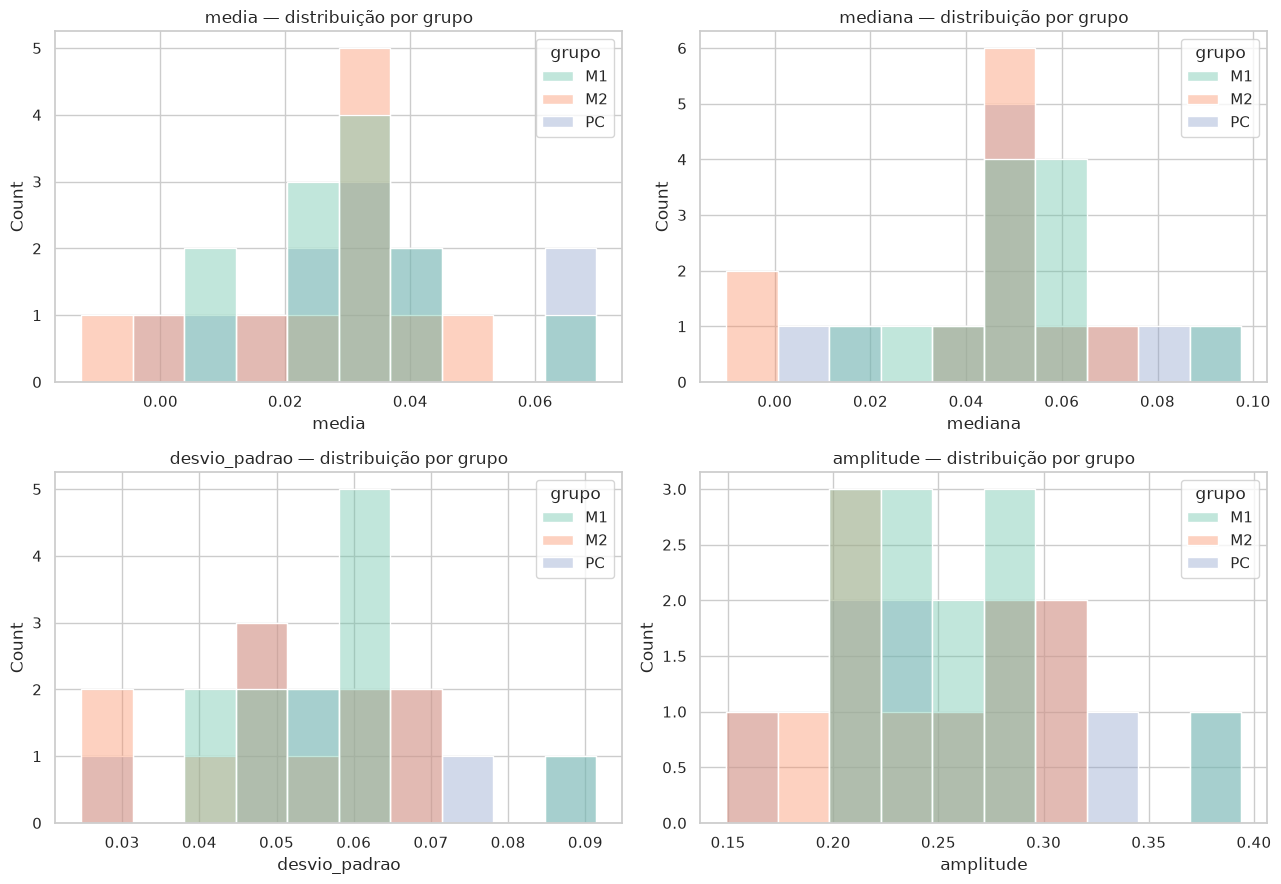

In [173]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, metrica in zip(axes.flatten(), metricas):
    sns.histplot(data=resumo, x=metrica, hue="grupo", bins=10,
        kde=False, alpha=0.4, ax=ax, palette="Set2")
    ax.set_title(f"{metrica} — distribuição por grupo")

plt.tight_layout()
plt.show()

Olhando o gráfico, vemos que os três grupos tem um movimento similar nas quatro métricas e se sobrepõem durante a maior parte das faixas. Esse comportamento é o esperado e condiz com as análises.

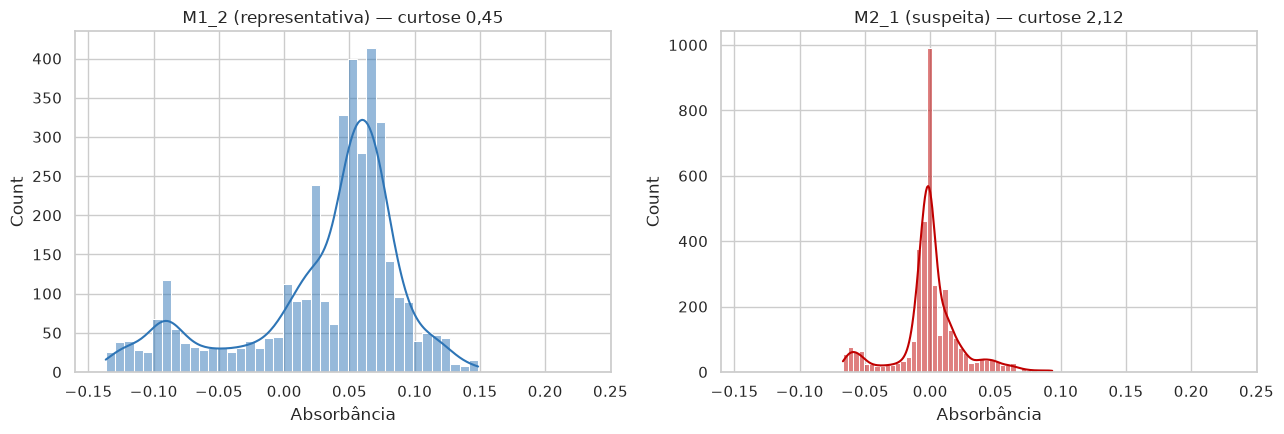

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(dataframe_limpo["M1_2"], bins=40, kde=True, ax=axes[0], color="#2E75B6")
axes[0].set_title("M1_2 (representativa) — curtose 0,45")

sns.histplot(dataframe_limpo["M2_1"], bins=40, kde=True, ax=axes[1], color="#C00000")
axes[1].set_title("M2_1 (suspeita) — curtose 2,12")

for ax in axes:
    ax.set_xlabel("Absorbância")
    ax.set_xlim(-0.16, 0.25)      # mesma escala nos dois — comparação justa

plt.tight_layout()
plt.show()

Aqui vemos mais um motivo de suspeita para M2_1. Sua curva mostra que uma quantidade muito elevada de valores estão muito próximas umas das outras e o gráfico fica mal distribuido.

---
# 🎲 Módulo 10 — Probabilidade

Vamos aplicar os conceitos fundamentais de probabilidade a eventos definidos sobre o próprio dataset.

### 10.1 Espaço amostral e eventos

Considere o experimento: **escolher uma amostra aleatoriamente**. O espaço amostral são as 35 amostras.

Vamos definir dois eventos:
- **A:** a amostra é saudável (`grupo == "PC"`)
- **B:** a amostra tem amplitude muito alta

In [175]:
total_amostras = len(resumo)

evento_A = resumo["grupo"] == "PC"
evento_B = resumo["amplitude"] > resumo["amplitude"].median()

P_A = evento_A.sum() / total_amostras
P_B = evento_B.sum() / total_amostras

print(f"P(A) = P(é saudável) = {P_A:.4f}")
print(f"P(B) = P(amplitude muito alta) = {P_B:.4f}")

P(A) = P(é saudável) = 0.3429
P(B) = P(amplitude muito alta) = 0.4857


### 10.2 Probabilidade conjunta P(A ∩ B)

In [176]:
P_A_e_B = (evento_A & evento_B).sum() / total_amostras
print(f"P(A ∩ B) = P(é saudável E tem amplitude alta) = {P_A_e_B:.4f}")

P(A ∩ B) = P(é saudável E tem amplitude alta) = 0.2000


### 10.3 Probabilidade condicional P(A | B)

"Dado que a amostra é saudável, qual a probabilidade de sua amplitude ser acima da mediana?"


In [177]:
P_A_dado_B = (evento_A & evento_B).sum() / evento_B.sum()
print(f"P(A | B) = {P_A_dado_B:.4f}")
print(f"Compare com P(A) = {P_A:.4f} (probabilidade sem a condição)")

P(A | B) = 0.4118
Compare com P(A) = 0.3429 (probabilidade sem a condição)


> 💡 Se `P(A | B)` for muito maior que `P(A)`, isso sugere que **células saudáveis têm maior chance de terem uma amplitude acima da mediana** — um indício de associação entre as variáveis, que investigaremos formalmente no Módulo 11.

### 10.4 Verificando independência

Dois eventos são independentes quando `P(A ∩ B) = P(A) × P(B)`.

In [178]:
produto_marginal = P_A * P_B

print(f"P(A) x P(B) = {produto_marginal:.4f}")
print(f"P(A ∩ B) observado = {P_A_e_B:.4f}")

if abs(produto_marginal - P_A_e_B) < 0.01:
    print("Os eventos parecem aproximadamente independentes.")
else:
    print("Os eventos NÃO parecem independentes — há indícios de associação.")

P(A) x P(B) = 0.1665
P(A ∩ B) observado = 0.2000
Os eventos NÃO parecem independentes — há indícios de associação.


---
# 🔗 Módulo 11 — Probabilidade Conjunta e Tabelas de Contingência

Vamos formalizar a investigação de associação entre variáveis categóricas usando tabelas de contingência.

### 11.1 Construindo a tabela de contingência

Vamos investigar a relação entre `grupo` e uma versão da amplitude. Essa métrica não tem cortes naturais e regulares, então nesse caso, usamos .qcut() para usar os tercis dos resultados para categorização.

In [179]:
resumo["faixa_amplitude"] = pd.qcut(resumo["amplitude"], 3, labels=["Baixa", "Media", "Alta"])

tabela_contingencia = pd.crosstab(resumo["grupo"], resumo["faixa_amplitude"])
tabela_contingencia

faixa_amplitude,Baixa,Media,Alta
grupo,,,
M1,4,4,4
M2,5,2,4
PC,3,5,4


### 11.2 Convertendo em probabilidades

In [180]:
tabela_conjunta = pd.crosstab(resumo["grupo"], resumo["faixa_amplitude"], normalize="all")
print("Probabilidade conjunta P(Grupo ∩ Faixa):")
tabela_conjunta.round(3)

Probabilidade conjunta P(Grupo ∩ Faixa):


faixa_amplitude,Baixa,Media,Alta
grupo,,,
M1,0.114,0.114,0.114
M2,0.143,0.057,0.114
PC,0.086,0.143,0.114


In [181]:
tabela_condicional = pd.crosstab(resumo["grupo"], resumo["faixa_amplitude"], normalize="index")
print("Probabilidade condicional P(Faixa | Grupo):")
tabela_condicional.round(3)

Probabilidade condicional P(Faixa | Grupo):


faixa_amplitude,Baixa,Media,Alta
grupo,,,
M1,0.333,0.333,0.333
M2,0.455,0.182,0.364
PC,0.250,0.417,0.333


### 11.3 Probabilidades marginais

In [182]:
marginais_grupo = tabela_conjunta.sum(axis=1)
marginais_faixa = tabela_conjunta.sum(axis=0)

print("Probabilidade marginal por grupo:")
print(marginais_grupo.round(3))
print("\nProbabilidade marginal por faixa de amplitude:")
print(marginais_faixa.round(3))

Probabilidade marginal por grupo:
grupo
M1    0.343
M2    0.314
PC    0.343
dtype: float64

Probabilidade marginal por faixa de amplitude:
faixa_amplitude
Baixa    0.343
Media    0.314
Alta     0.343
dtype: float64


### 11.4 Visualizando a associação

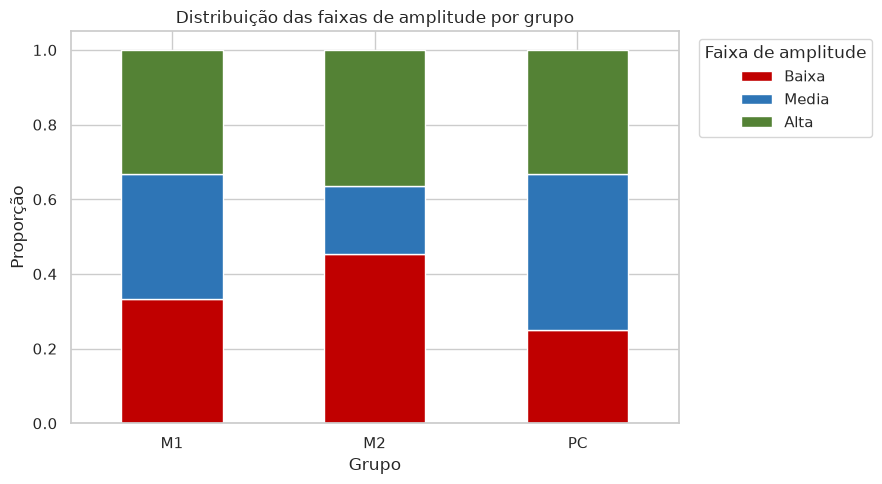

In [183]:
tabela_condicional.plot(kind="bar", stacked=True, figsize=(9, 5), color=["#C00000", "#2E75B6", "#548235"])
plt.title("Distribuição das faixas de amplitude por grupo")
plt.ylabel("Proporção")
plt.xlabel("Grupo")
plt.legend(title="Faixa de amplitude", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> 💡 **Interpretação:** as três barras são extremamente similares umas às outras, com uma pequena exceção em M2, por um motivo já definido. Isso dá a entender que há pouquíssima ou nenhuma associação entre a amplitude de uma amostra e seu grupo, ela pode estar em qualquer um dos três numa mesma chance.

---
# 🔄 Módulo 12 — Correlação

Vamos investigar a correlação entre variáveis numéricas, usando os coeficientes de Pearson e Spearman.

### 12.1 Matriz de correlação (Pearson)

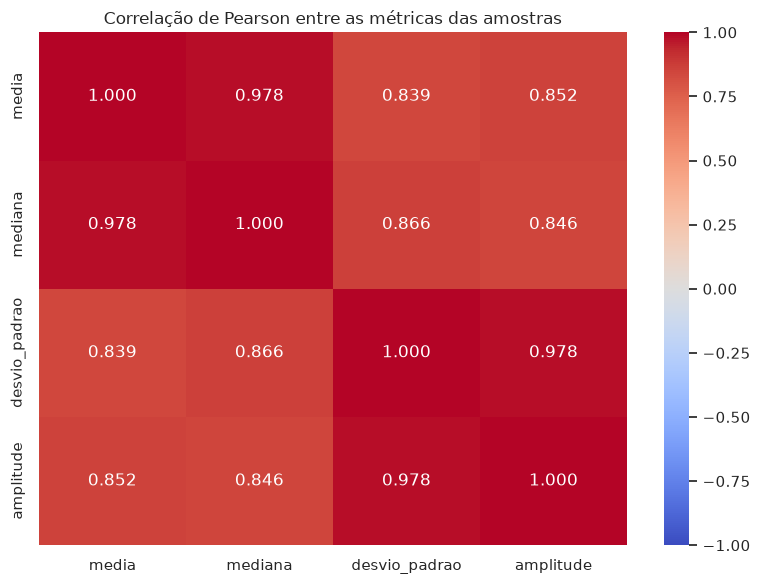

In [184]:
variaveis_interesse = metricas

matriz_corr = resumo[variaveis_interesse].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlação de Pearson entre as métricas das amostras")
plt.tight_layout()
plt.show()

### 12.2 Correlação de Spearman

Mais robusta a outliers e capaz de capturar relações monotônicas não necessariamente lineares.

In [185]:
matriz_corr_spearman = resumo[variaveis_interesse].corr(method="spearman")

divergencia = (matriz_corr - matriz_corr_spearman).abs()
print("Maior divergência entre Pearson e Spearman:", divergencia.values.max().round(3))

Maior divergência entre Pearson e Spearman: 0.097


### 12.3 Identificando as correlações mais fortes

In [186]:
corr_pares = matriz_corr.unstack().sort_values(ascending=False)
corr_pares = corr_pares[corr_pares < 1.0]
corr_pares.drop_duplicates()

desvio_padrao  amplitude        0.977810
mediana        media            0.977639
desvio_padrao  mediana          0.865770
media          amplitude        0.851655
amplitude      mediana          0.846388
media          desvio_padrao    0.839106
dtype: float64

> ⚠️ **Correlação não implica causalidade.** desvio_padrao e amplitude apresentam correlação de 0,978 — o que é esperado, já que ambas medem dispersão do mesmo espectro, mas nenhuma "causa" a outra, as duas tratam de coisas parecidas, a intensidade global da medição. Da mesma forma, media e mediana (0,978), que descrevem valores centrais.

### 12.4 Correlação entre amostras

In [187]:
matriz_corr_amostras = dataframe_limpo[variaveis_numericas].corr()

correlacao_entre_grupos = (
    matriz_corr_amostras.groupby(resumo["grupo"]).mean()
    .T.groupby(resumo["grupo"]).mean()
)

correlacao_entre_grupos.round(4)

grupo,M1,M2,PC
grupo,,,
M1,0.9730,0.8968,0.9711
M2,0.8968,0.8319,0.8969
PC,0.9711,0.8969,0.9702


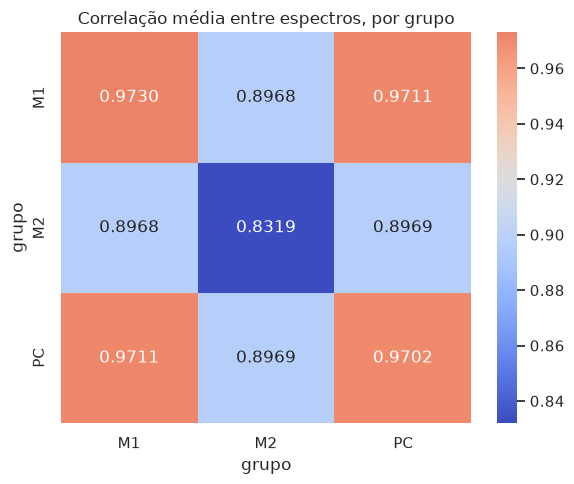

In [188]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlacao_entre_grupos, annot=True, fmt=".4f", cmap="coolwarm", center=0.92)
plt.title("Correlação média entre espectros, por grupo")
plt.tight_layout()
plt.show()

Observando esse gráfico, é possível ver um comportamento anômalo: nos pontos de interseção com `M2`, há uma grande diminuição de valores se comparadas aos outros. Isso acontece por causa de `M2_1` e `M2_3`.

In [189]:
sem_anomalas = [c for c in variaveis_numericas if c not in ["M2_1", "M2_3"]]

correlacao_sem_anomalas = (
    dataframe_limpo[sem_anomalas].corr()
    .groupby(resumo["grupo"]).mean()
    .T.groupby(resumo["grupo"]).mean()
)

correlacao_sem_anomalas.round(4)

grupo,M1,M2,PC
grupo,,,
M1,0.9730,0.9652,0.9711
M2,0.9652,0.9688,0.9615
PC,0.9711,0.9615,0.9702


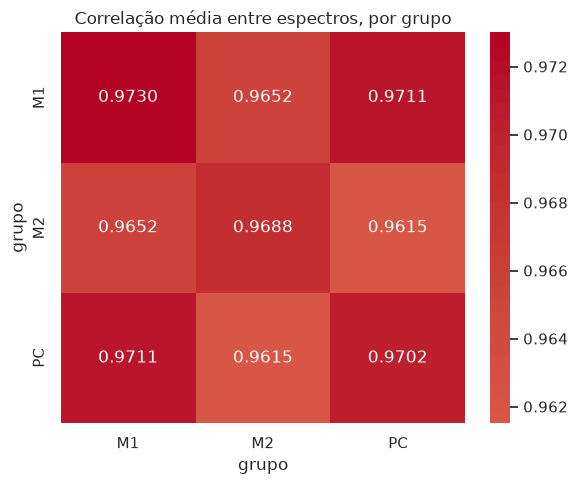

In [190]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlacao_sem_anomalas, annot=True, fmt=".4f", cmap="coolwarm", center=0.92)
plt.title("Correlação média entre espectros, por grupo")
plt.tight_layout()

plt.show()

### 12.5 Conclusões

Fazendo a remoção de ambos, os valores assumem os valores esperados, maiores nas interseções, por serem sempre mais próximos à si mesmo que à outros. `M1↔PC` (0,9711) é praticamente igual a `PC↔PC` (0,9702) — espectros de células saudáveis não são mais parecidos entre si do que com os de carcinoma.

Conclui-se que a correlação não interfere de forma alguma na classe celular. É a quarta evidência convergente, após os Módulos 9, 10 e 11. A informação discriminante existe, mas depende de remover o efeito de intensidade global (Módulo 15) e isolar faixas espectrais específicas (Módulo 16).

---
# 🖼️ Módulo 13 — Visualização de Dados

Vamos aplicar os principais tipos de gráficos apresentados na apostila para explorar visualmente o dataset.

### 13.1 Histograma

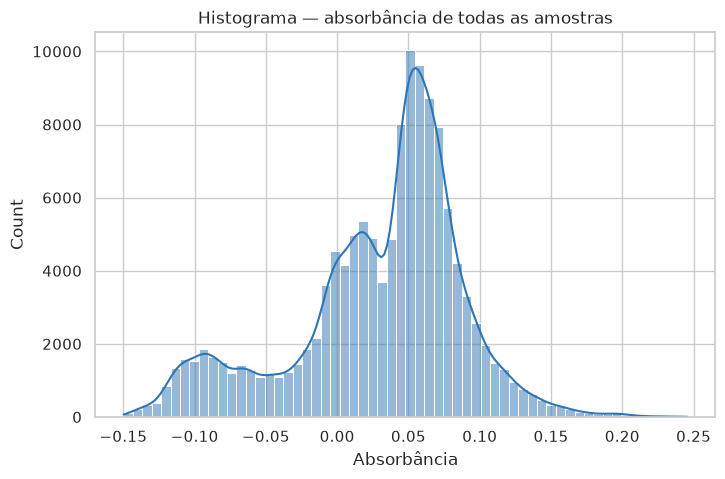

In [191]:
plt.figure(figsize=(8, 5))
sns.histplot(dataframe_limpo[variaveis_numericas].values.ravel(), bins=60, kde=True, color="#2E75B6")
plt.title("Histograma — absorbância de todas as amostras")
plt.xlabel("Absorbância")
plt.show()

### 13.2 Boxplot (comparando grupos)

/tmp/ipykernel_14677/1735135439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="grupo", y="amplitude", data=resumo, order=["PC", "M1", "M2"], palette="Blues")


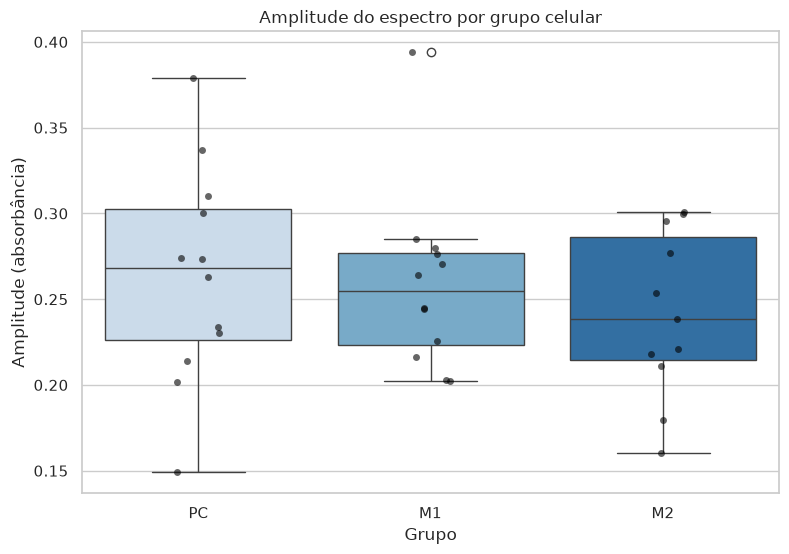

In [192]:
plt.figure(figsize=(9, 6))
sns.boxplot(x="grupo", y="amplitude", data=resumo, order=["PC", "M1", "M2"], palette="Blues")
sns.stripplot(x="grupo", y="amplitude", data=resumo, order=["PC", "M1", "M2"], color="black", size=5, alpha=0.6)
plt.title("Amplitude do espectro por grupo celular")
plt.xlabel("Grupo")
plt.ylabel("Amplitude (absorbância)")
plt.show()

### 13.3 Gráfico de dispersão (scatter plot)

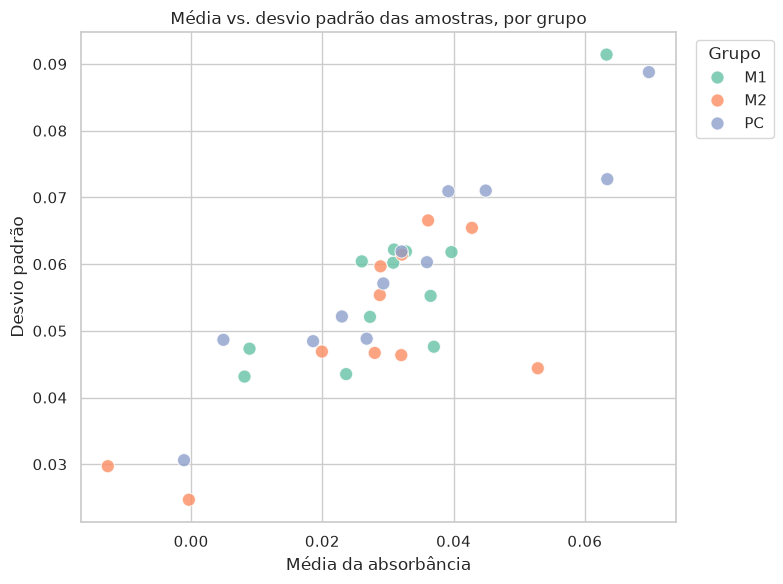

In [193]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="media", y="desvio_padrao", hue="grupo", data=resumo, palette="Set2", s=90, alpha=0.8)
plt.title("Média vs. desvio padrão das amostras, por grupo")
plt.xlabel("Média da absorbância")
plt.ylabel("Desvio padrão")
plt.legend(title="Grupo", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### 13.4 Gráfico de barras

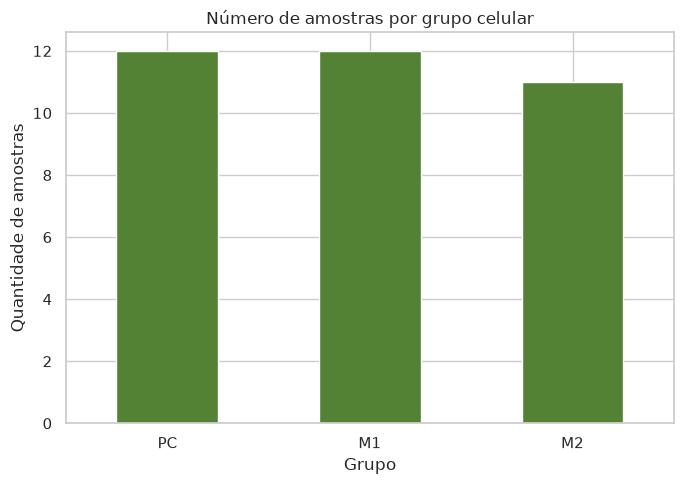

In [194]:
plt.figure(figsize=(7, 5))
resumo["grupo"].value_counts().reindex(["PC", "M1", "M2"]).plot(kind="bar", color="#548235")
plt.title("Número de amostras por grupo celular")
plt.xlabel("Grupo")
plt.ylabel("Quantidade de amostras")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 13.5 Gráfico de linhas (tendência ao longo do tempo)

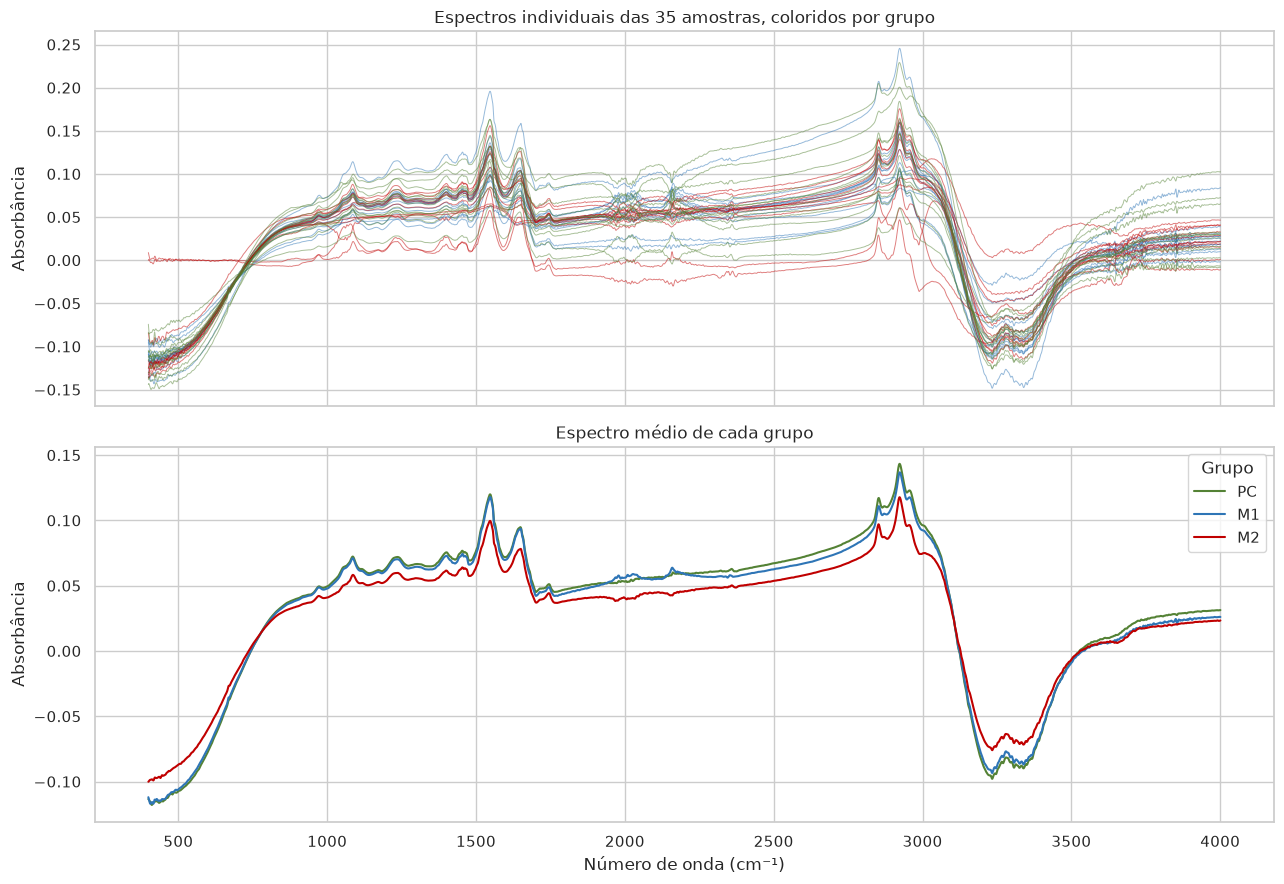

In [195]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
cores = {"PC": "#548235", "M1": "#2E75B6", "M2": "#C00000"}

for amostra in variaveis_numericas:
    g = resumo.loc[amostra, "grupo"]
    axes[0].plot(dataframe_limpo["wavenumber"], dataframe_limpo[amostra], color=cores[g], linewidth=0.7, alpha=0.5)

axes[0].set_title("Espectros individuais das 35 amostras, coloridos por grupo")
axes[0].set_ylabel("Absorbância")

for g in ["PC", "M1", "M2"]:
    amostras_g = [c for c in variaveis_numericas if resumo.loc[c, "grupo"] == g]
    axes[1].plot(dataframe_limpo["wavenumber"], dataframe_limpo[amostras_g].mean(axis=1),color=cores[g], linewidth=1.5, label=g)

axes[1].set_title("Espectro médio de cada grupo")
axes[1].set_xlabel("Número de onda (cm⁻¹)")
axes[1].set_ylabel("Absorbância")
axes[1].legend(title="Grupo")

plt.tight_layout()
plt.show()


### 13.5.1 Análise de possíveis variáveis-alvo para regressão

Como o dataset original não tem variáveis numéricas contínuas que possam ser utilizadas diretamente como alvo de regressão, serão avaliadas estatísticas derivadas dos espectros.

A mediana de intensidade espectral será utilizada como medida de tendência central entre diferentes faixas de número de onda. Assim, é possível representar o comportamento geral do espectro em uma determinada região, lidando com a influência de oscilações em pontos específicos e valores muito extremos.

Inicialmente, compararemos as faixas de 1000–1500cm⁻¹ e 2000–2500cm⁻¹. Essas faixas foram escolhidas baseadas na análise visual do gráfico, onde são perceptivelmente mais estáveis que seus vizinhos, com variações menos extremas, o que ajuda a encontrar uma medida de tendência central.

A escolha final será baseada principalmente na variabilidade apresentada pela mediana entre as diferentes amostras, além da interpretação do comportamento espectral observado na análise exploratória.

Um detalhe interessante é que a demonstração visual da anomalia de M2_1, em vermelho no gráfico de cima. A linha achatada se destaca sobre as outras mesmo quando há outras por perto e se sobrepondo.

In [196]:
faixas = {
    "mediana_1000_1500": (1000, 1500),
    "mediana_2000_2500": (2000, 2500)
}

medianas_faixas = {}

for nome, (inicio, fim) in faixas.items():
    valores_faixa = dataframe[
        (dataframe["wavenumber"] >= inicio) &
        (dataframe["wavenumber"] <= fim)
    ]

    medianas_faixas[nome] = valores_faixa[variaveis_numericas].median()

medianas_faixas = pd.DataFrame(medianas_faixas)
medianas_faixas.describe()

,mediana_1000_1500,mediana_2000_2500
count,35.000000,35.000000
mean,0.061964,0.054931
std,0.020407,0.028558
min,0.011624,-0.020050
25%,0.051601,0.048078
50%,0.066324,0.057062
75%,0.071156,0.065888
max,0.105329,0.120227


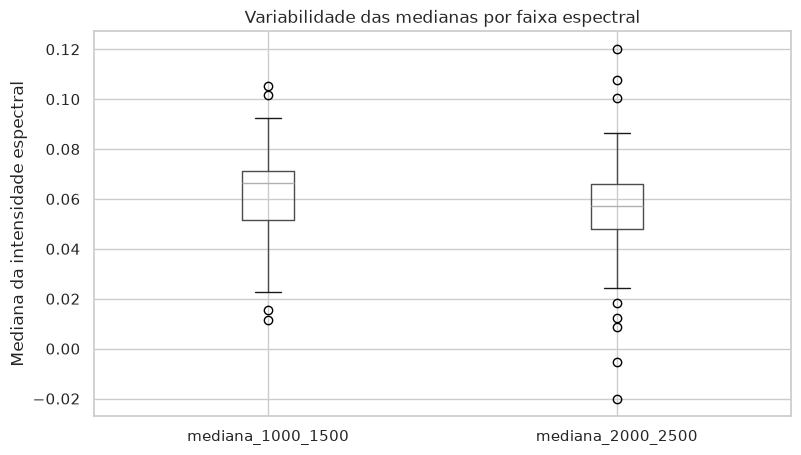

In [197]:
medianas_faixas.boxplot()
plt.ylabel("Mediana da intensidade espectral")
plt.title("Variabilidade das medianas por faixa espectral")
plt.show()

Como podemos observar no boxplot e nos valores apresentados pelo `describe()`, a mediana da faixa de 2000–2500 cm⁻¹ apresenta maior variabilidade entre as amostras, quando comparada à faixa de 1000–1500 cm⁻¹. Essa maior dispersão fornece uma maior diferenciação entre os valores da variável-alvo, tornando a faixa mais adequada para investigar um problema de regressão, desde que existam relações relevantes com possíveis variáveis preditoras.

### 13.5.2 Definição da variável-alvo da regressão

A partir da comparação entre as faixas avaliadas, foi escolhida a faixa de 2000–2500 cm⁻¹ como base para a variável-alvo da regressão.

Ela será definida como a mediana da intensidade espectral nessa faixa. A mediana foi escolhida por representar o comportamento central dos valores da região, sendo menos influenciada por oscilações pontuais. Desta forma, será utilizada como variável-alvo contínua, representando o valor que se pretende prever para cada amostra.

In [198]:
resumo["mediana_2000_2500"] = medianas_faixas["mediana_2000_2500"]

resumo[["grupo", "mediana_2000_2500"]].round(5)

,grupo,mediana_2000_2500
M1_1,M1,0.01825
M1_2,M1,0.05613
M1_3,M1,0.06192
M1_4,M1,0.02434
M1_5,M1,0.06284
M1_6,M1,0.06024
M1_7,M1,0.10779
M1_8,M1,0.05241
M1_9,M1,0.04795
M1_10,M1,0.07344


### 13.5.3 Relação entre o alvo e as regiões espectrais

Para investigar possíveis variáveis preditoras da regressão, serão calculadas medidas de tendência central em regiões do espectro que não se sobrepõem à faixa utilizada para construir a variável-alvo. Essas relações entre características e a variável-alvo serão analisadas por meio de correlação e visualizações de dispersão.

In [199]:
faixas_previsao = {
    "media_faixa_400_1000": (400, 1000),
    "media_faixa_1000_2000": (1000, 2000),
    "media_faixa_2500_3000": (2500, 3000),
    "media_faixa_3000_4000": (3000, 4000)
}

for nome, (inicio, fim) in faixas_previsao.items():
    dentro = (
        (dataframe_limpo["wavenumber"] >= inicio) &
        (dataframe_limpo["wavenumber"] <= fim)
    )

    resumo[nome] = dataframe_limpo.loc[
        dentro, variaveis_numericas
    ].mean()

features_regressao = list(faixas_previsao.keys())

resumo[features_regressao + ["mediana_2000_2500"]].round(5)

,media_faixa_400_1000,media_faixa_1000_2000,media_faixa_2500_3000,media_faixa_3000_4000,mediana_2000_2500
M1_1,-0.02840,0.03747,0.04586,-0.02336,0.01825
M1_2,-0.03162,0.06557,0.09062,-0.00877,0.05613
M1_3,-0.02842,0.06085,0.07987,0.01791,0.06192
M1_4,-0.02917,0.04314,0.04815,-0.02985,0.02434
M1_5,-0.02607,0.06856,0.09051,-0.01893,0.06284
M1_6,-0.02754,0.06933,0.09249,-0.01143,0.06024
M1_7,-0.03411,0.10649,0.16573,0.00530,0.10779
M1_8,-0.02857,0.06503,0.08150,-0.02143,0.05241
M1_9,-0.03019,0.04605,0.06228,0.00214,0.04795
M1_10,-0.02743,0.07201,0.10255,-0.00082,0.07344


In [200]:
correlacoes_regressao = (
    resumo[features_regressao + ["mediana_2000_2500"]]
    .corr(method="pearson")["mediana_2000_2500"]
    .drop("mediana_2000_2500")
    .sort_values(key=abs, ascending=False)
)

correlacoes_regressao.round(4)

media_faixa_2500_3000    0.9656
media_faixa_1000_2000    0.9547
media_faixa_3000_4000    0.7726
media_faixa_400_1000    -0.5851
Name: mediana_2000_2500, dtype: float64

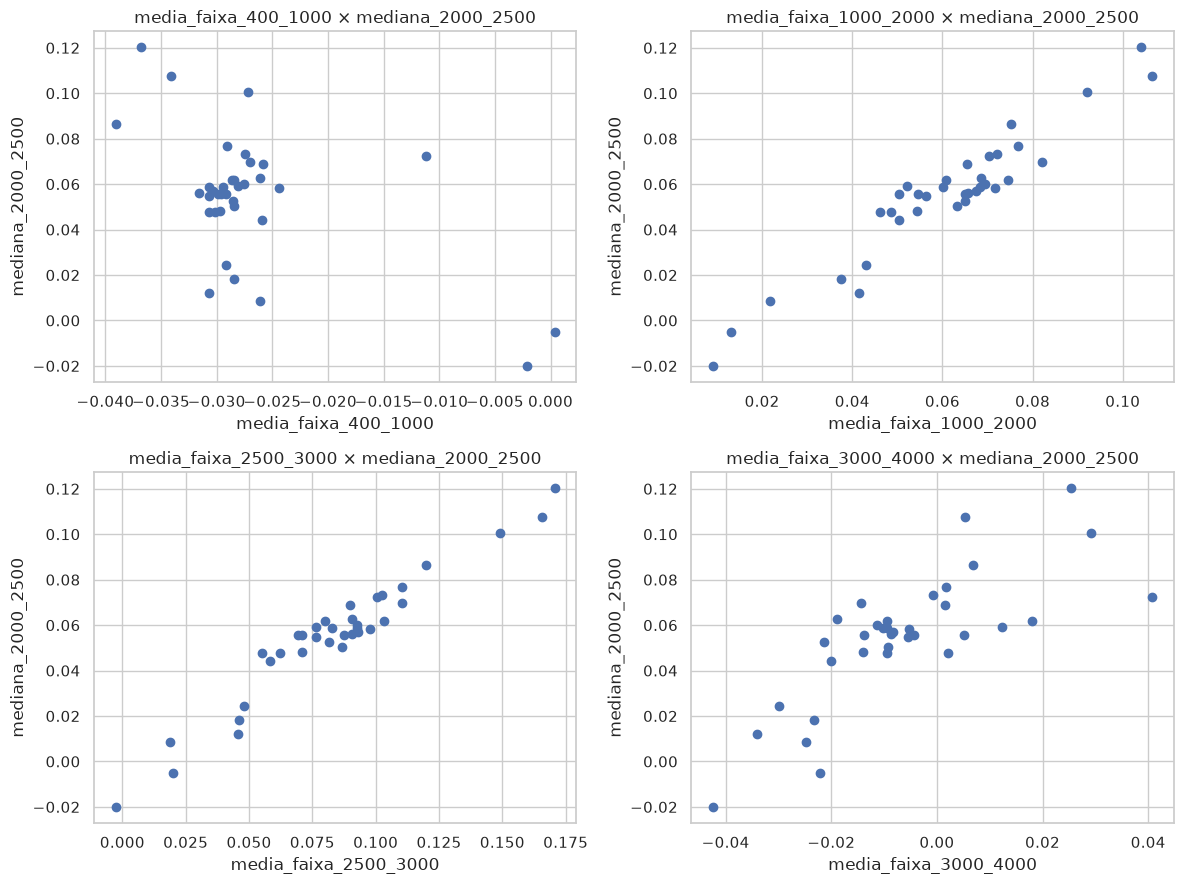

In [201]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flatten(), features_regressao):
    ax.scatter(
        resumo[feature],
        resumo["mediana_2000_2500"]
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("mediana_2000_2500")
    ax.set_title(f"{feature} × mediana_2000_2500")

plt.tight_layout()
plt.show()

### 13.5.3 Multicolinearidade

Por termos valores muito correlacionados à faixa da variável-alvo, devemos checar se elas não se correlacionam também entre si, e se dessa forma não trazem dados redundântes à regressão.

In [202]:
correlacao_features = resumo[
    features_regressao
].corr(method="pearson")

correlacao_features.round(4)

,media_faixa_400_1000,media_faixa_1000_2000,media_faixa_2500_3000,media_faixa_3000_4000
media_faixa_400_1000,1.0000,-0.5744,-0.5336,-0.2172
media_faixa_1000_2000,-0.5744,1.0000,0.9842,0.6260
media_faixa_2500_3000,-0.5336,0.9842,1.0000,0.6893
media_faixa_3000_4000,-0.2172,0.6260,0.6893,1.0000


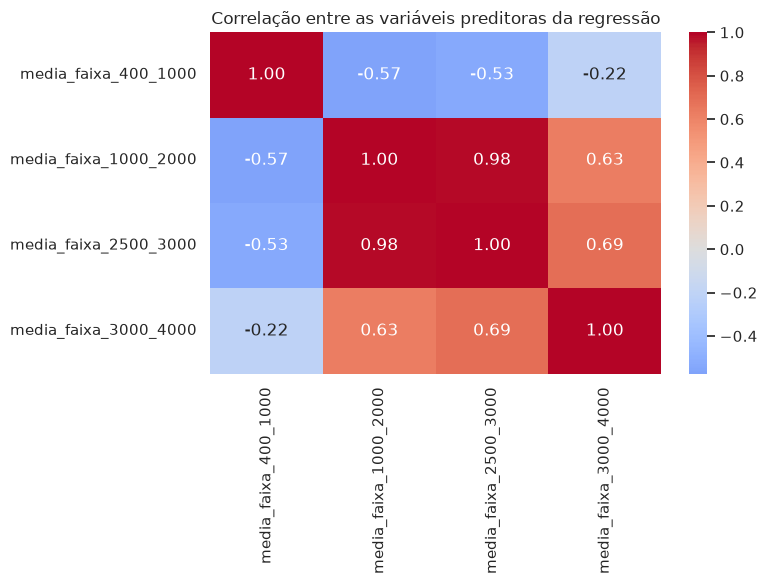

In [203]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao_features,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre as variáveis preditoras da regressão")
plt.tight_layout()
plt.show()

As regiões de 1000–2000 cm⁻¹ e 2500–3000 cm⁻¹ apresentaram correlação muito forte entre si (r = 0,9842), indicando possível redundância entre as características. Como a região de 2500–3000 cm⁻¹ apresentou correlação ligeiramente maior com a variável-alvo (r = 0,9656, contra r = 0,9547 para 1000–2000 cm⁻¹), optou-se por priorizar essa característica e evitar a inclusão simultânea das duas.

In [204]:
features_regressao_selecionadas = [
    "media_faixa_400_1000",
    "media_faixa_2500_3000",
    "media_faixa_3000_4000"
]

resumo[features_regressao_selecionadas].corr().round(4)

,media_faixa_400_1000,media_faixa_2500_3000,media_faixa_3000_4000
media_faixa_400_1000,1.0000,-0.5336,-0.2172
media_faixa_2500_3000,-0.5336,1.0000,0.6893
media_faixa_3000_4000,-0.2172,0.6893,1.0000


As outras não possuem correlação tão elevada, então continuaram a ser usadas.

### 13.5.6 Análise gráfica das relações com a variável-alvo

Após a análise das correlações entre as variáveis preditoras e a variável-alvo, serão utilizadas visualizações de dispersão para analisar graficamente essas relações.

Para cada variável preditora selecionada, será construído um gráfico relacionando sua média espectral com a `mediana_2000_2500`. Também será apresentada uma reta de regressão linear, permitindo observar a tendência geral da relação entre as variáveis.

Essa análise complementa os valores de correlação de Pearson, permitindo verificar visualmente se as relações observadas apresentam comportamento aproximadamente linear e se existem padrões ou observações que possam influenciar essas relações.

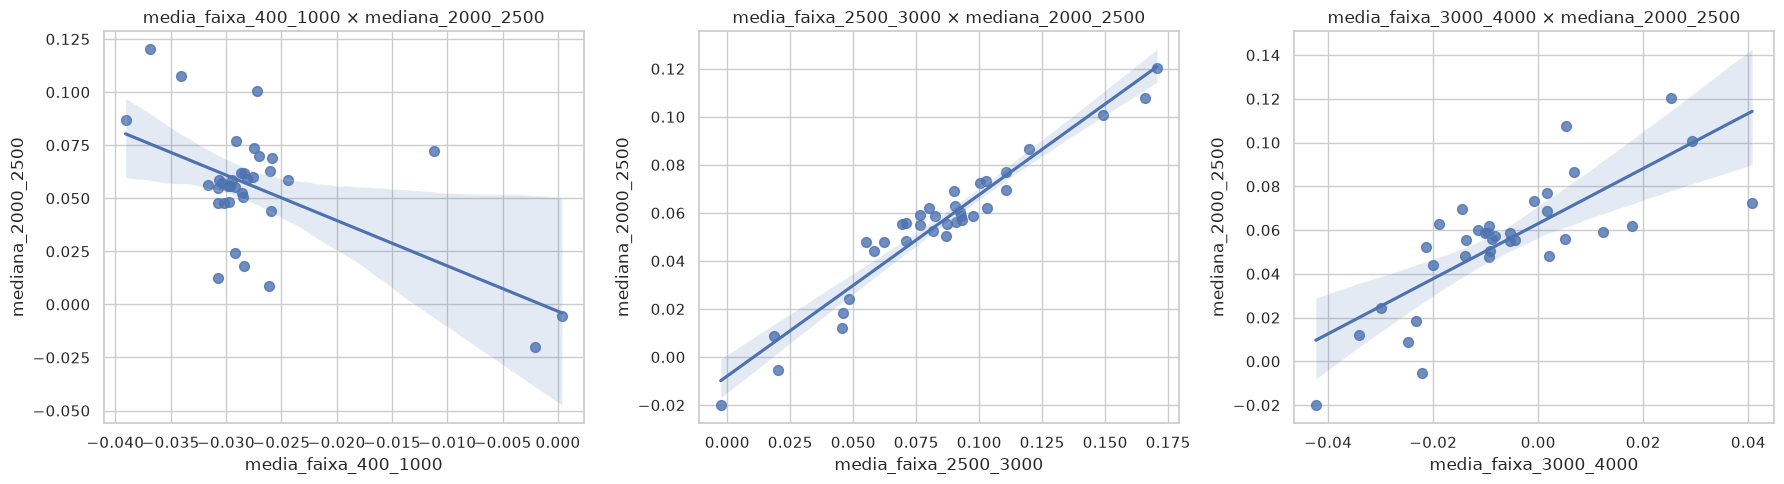

In [205]:
features_regressao = [
    "media_faixa_400_1000",
    "media_faixa_2500_3000",
    "media_faixa_3000_4000"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features_regressao):
    sns.regplot(
        data=resumo,
        x=feature,
        y="mediana_2000_2500",
        ax=ax,
        scatter_kws={"s": 50}
    )

    ax.set_title(f"{feature} × mediana_2000_2500")
    ax.set_xlabel(feature)
    ax.set_ylabel("mediana_2000_2500")

plt.tight_layout()
plt.show()

### 13.5.7 Coeficiente de determinação das relações

Para complementar a análise das correlações, será calculado o coeficiente de determinação (R²) de uma regressão linear simples entre cada variável preditora e a variável-alvo.

O R² representa a proporção da variabilidade observada na variável-alvo que é explicada pelo modelo linear utilizando uma determinada variável preditora.

Valores mais próximos de 1 indicam que a relação linear consegue explicar uma parcela maior da variação observada no alvo. Entretanto, esses resultados serão utilizados apenas como análise exploratória das relações entre as variáveis, e não como avaliação de um modelo de regressão definitivo.

In [206]:
from sklearn.linear_model import LinearRegression

for feature in features_regressao:
    X = resumo[[feature]]
    y = resumo["mediana_2000_2500"]

    modelo = LinearRegression()
    modelo.fit(X, y)

    r2 = modelo.score(X, y)

    print(f"{feature}: R² = {r2:.4f}")

media_faixa_400_1000: R² = 0.3424
media_faixa_2500_3000: R² = 0.9324
media_faixa_3000_4000: R² = 0.5969


### 13.5.8 Percepções e recomendações para regressão

A partir das análises realizadas, as variáveis `media_faixa_2500_3000`, `media_faixa_3000_4000` e `media_faixa_400_1000` foram selecionadas como possíveis variáveis preditoras para o problema de regressão.

Um possível desafio para a regressão é que as relações observadas podem não ser perfeitamente lineares. Além disso, como o dataset possui apenas 35 espectros, a quantidade de observações é relativamente pequena para a construção de um modelo, o que pode aumentar o risco de overfitting. Também será necessário verificar a influência de possíveis observações atípicas sobre o ajuste do modelo.

Como modelos iniciais, poderiam ser testados algoritmos de regressão linear, devido às relações lineares observadas, e posteriormente modelos capazes de representar relações não lineares, como Random Forest Regressor. A comparação entre diferentes algoritmos permitiria verificar se a relação entre as regiões espectrais e a variável-alvo é adequadamente representada por um modelo linear ou se modelos mais complexos apresentam vantagens.

In [207]:
resumo_features = pd.DataFrame({
    "feature": features_regressao,
    "correlacao_com_target": [
        resumo[feature].corr(resumo["mediana_2000_2500"])
        for feature in features_regressao
    ]
})

resumo_features["R2"] = [
    LinearRegression()
    .fit(
        resumo[[feature]],
        resumo["mediana_2000_2500"]
    )
    .score(
        resumo[[feature]],
        resumo["mediana_2000_2500"]
    )
    for feature in features_regressao
]

resumo_features.sort_values(
    "correlacao_com_target",
    ascending=False
).round(4)

,feature,correlacao_com_target,R2
1,media_faixa_2500_3000,0.9656,0.9324
2,media_faixa_3000_4000,0.7726,0.5969
0,media_faixa_400_1000,-0.5851,0.3424


### 13.6 Identificação do target para classificação

Para o problema de classificação, a variável-alvo escolhida será a variável `grupo`, que representa a categoria à qual cada espectro pertence.

As categorias presentes no dataset são:

- **PC**: células cervicais saudáveis;
- **M1**: células de carcinoma primário;
- **M2**: células de carcinoma metastático.

Essa variável é adequada para um problema de classificação porque representa três categorias distintas que podem ser utilizadas como classes de saída de um modelo supervisionado.

Nesse contexto, o objetivo do problema será analisar se as características extraídas dos espectros de ATR-FTIR apresentam diferenças suficientes entre os grupos para permitir a identificação da classe de uma nova amostra.

É importante destacar que `grupo` será utilizado como **variável-alvo**, e não como variável preditora. As informações espectrais e as características extraídas dos espectros serão utilizadas como possíveis variáveis independentes para tentar prever a classe da amostra.

Como as quantidades de amostras são próximas entre as três categorias, não há inicialmente um problema grave de desbalanceamento de classes. A análise seguinte deverá verificar quais características apresentam maior diferenciação entre PC, M1 e M2 e, portanto, podem ser mais relevantes para um futuro modelo de classificação.

In [208]:
campos = ["media_faixa_400_1000", "media_faixa_2500_3000", "media_faixa_3000_4000", "mediana_2000_2500", "amplitude", "desvio_padrao"]
resumo_grupo = resumo.groupby("grupo")[campos].median(numeric_only=True).reset_index()
resumo_grupo

,grupo,media_faixa_400_1000,media_faixa_2500_3000,media_faixa_3000_4000,mediana_2000_2500,amplitude,desvio_padrao
0,M1,-0.028495,0.085639,-0.007109,0.058183,0.254641,0.057727
1,M2,-0.029058,0.082579,-0.009392,0.057062,0.238464,0.046893
2,PC,-0.028831,0.089826,-0.009688,0.056993,0.268113,0.058695


### 13.7 Comparação das características entre os grupos

Para facilitar a comparação entre as classes, podemos agrupar as amostras de acordo com a variável `grupo` e calcular a mediana de algumas características.

Essa tabela possui apenas finalidade descritiva. Ela permite observar o comportamento típico de cada grupo, mas não será utilizada diretamente como entrada para o modelo de classificação.

Para a classificação, continuaremos utilizando as 35 amostras individuais presentes em `resumo`, mantendo a variabilidade existente dentro de cada grupo.

In [209]:
resumo_por_grupo = (
    resumo
    .groupby("grupo")[campos]
    .median()
    .reset_index()
)

resumo_por_grupo

,grupo,media_faixa_400_1000,media_faixa_2500_3000,media_faixa_3000_4000,mediana_2000_2500,amplitude,desvio_padrao
0,M1,-0.028495,0.085639,-0.007109,0.058183,0.254641,0.057727
1,M2,-0.029058,0.082579,-0.009392,0.057062,0.238464,0.046893
2,PC,-0.028831,0.089826,-0.009688,0.056993,0.268113,0.058695


### 13.8 Distribuição das características por grupo

A tabela de valores centrais permite comparar os grupos, mas não mostra a dispersão das amostras.

Por isso, serão utilizados boxplots para verificar visualmente se as distribuições das características apresentam diferenças entre `PC`, `M1` e `M2`.

Essa análise é importante porque uma característica pode apresentar médias ou medianas diferentes entre os grupos, mas ainda possuir grande sobreposição entre suas distribuições.

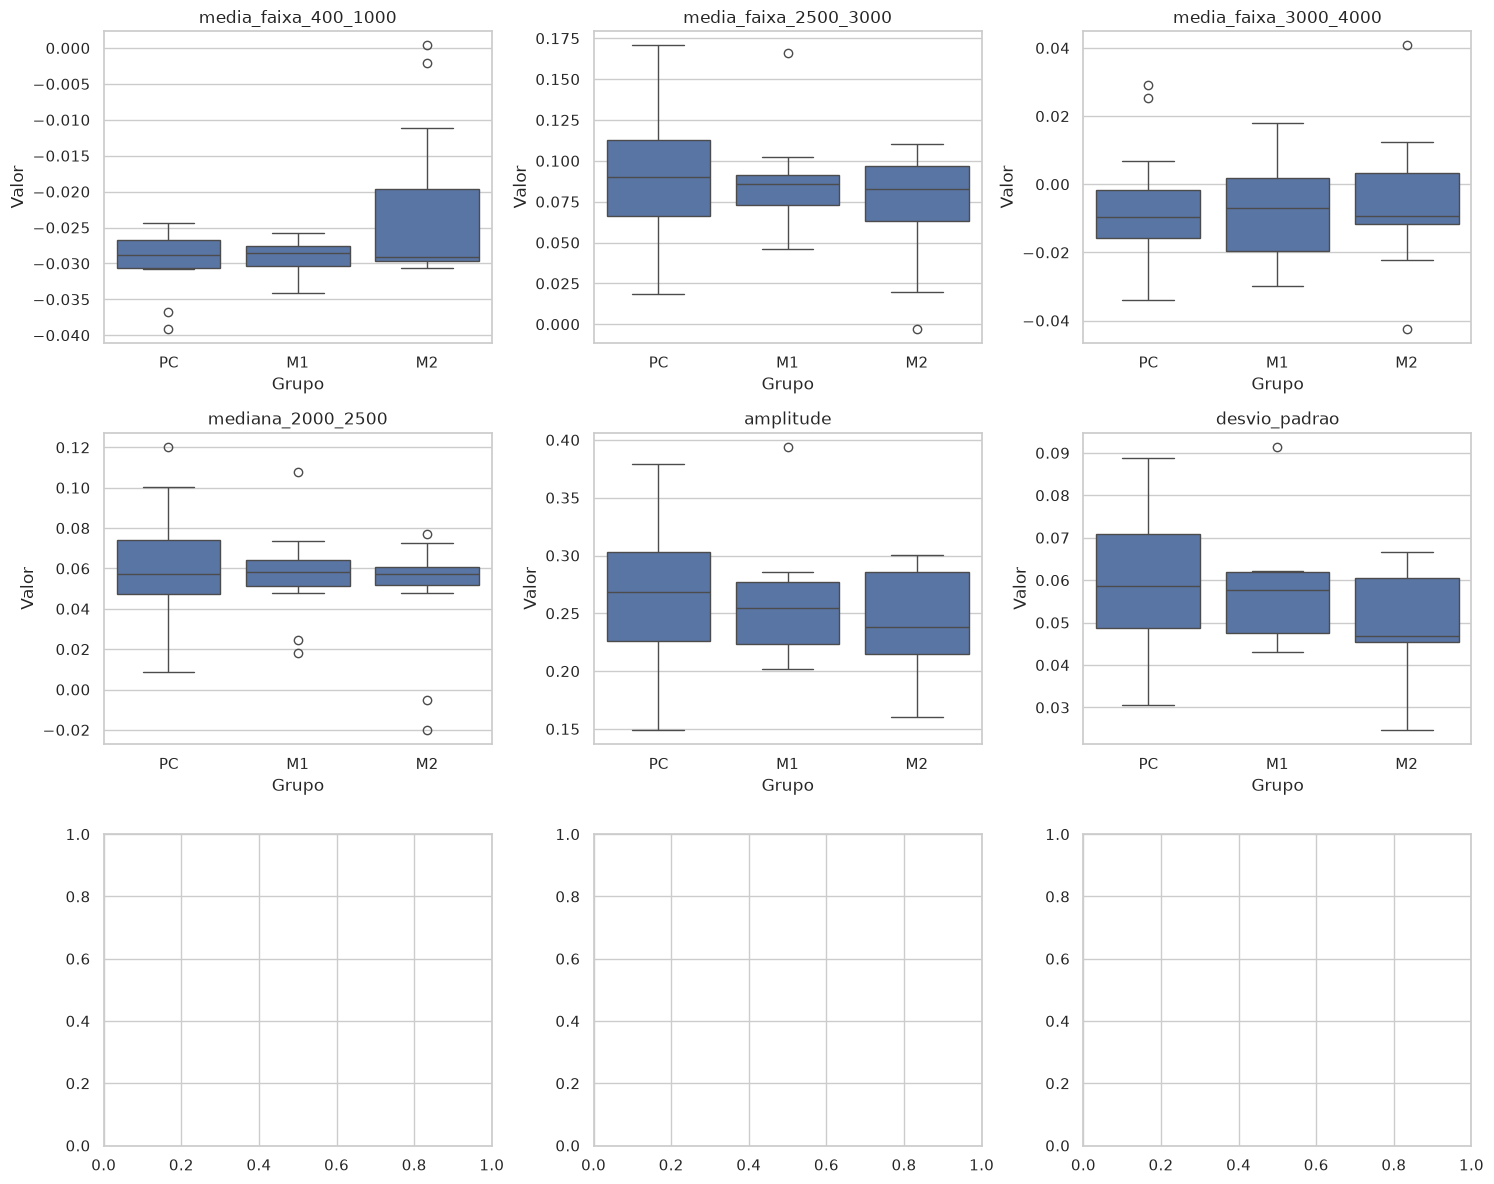

In [210]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), campos):
    sns.boxplot(
        data=resumo,
        x="grupo",
        y=feature,
        order=["PC", "M1", "M2"],
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Grupo")
    ax.set_ylabel("Valor")

plt.tight_layout()
plt.show()

### 13.10 Teste de diferença entre os grupos

Para complementar a análise visual, será aplicado o teste ANOVA de uma via para cada característica.

O teste verifica se existem diferenças estatisticamente significativas entre as médias dos três grupos (`PC`, `M1` e `M2`).

A hipótese nula considera que os grupos possuem a mesma média para a característica analisada. Um valor de `p` pequeno fornece evidência contra essa hipótese.

Como temos apenas 35 amostras, os resultados serão utilizados como evidência exploratória para seleção de características, e não como prova definitiva de que uma feature será capaz de classificar corretamente as amostras.

In [211]:
resultados_anova = []

for feature in campos:
    grupos = [
        resumo.loc[resumo["grupo"] == classe, feature]
        for classe in ["PC", "M1", "M2"]
    ]

    estatistica, p_valor = stats.f_oneway(*grupos)

    resultados_anova.append({
        "feature": feature,
        "estatistica_F": estatistica,
        "p_valor": p_valor
    })

anova = pd.DataFrame(resultados_anova)

anova = anova.sort_values("p_valor")

anova.round(5)

,feature,estatistica_F,p_valor
0,media_faixa_400_1000,3.13703,0.05701
5,desvio_padrao,1.45517,0.24839
1,media_faixa_2500_3000,0.74668,0.48201
3,mediana_2000_2500,0.57626,0.56772
4,amplitude,0.52817,0.59474
2,media_faixa_3000_4000,0.06689,0.93543


---
# 🛠️ Módulo 14 — Engenharia de Features

Vamos criar novas variáveis (features) a partir das colunas existentes, aplicando as técnicas apresentadas na apostila.

### 14.1 Discretização (binning)

Usando as sinalizações `total_sinalizacoes` (nota numérica) em uma faixa categórica.

In [212]:
resumo["faixa_qualidade"] = pd.cut(
    resumo["total_sinalizacoes"],
    bins=[-1, 0, 1, 10],
    labels=["Boa", "Atencao", "Revisar"]
)

resumo[["grupo", "total_sinalizacoes", "faixa_qualidade"]] \
    .sort_values("total_sinalizacoes", ascending=False).head(8)

,grupo,total_sinalizacoes,faixa_qualidade
M1_7,M1,4,Revisar
M2_1,M2,3,Revisar
PC_2,PC,3,Revisar
PC_7,PC,2,Revisar
PC_12,PC,2,Revisar
M2_3,M2,2,Revisar
M1_1,M1,1,Atencao
PC_8,PC,1,Atencao


### 14.2 Features temporais

A base não possui variáveis temporais, então essa etapa pode ser ignorada.

### 14.3 Transformação logarítmica

Reduz a assimetria de variáveis com distribuição enviesada, a maioria já possuia valores baixos de assimetria, então pouco mudou.

In [213]:
comparacao_log = pd.DataFrame({
    "assimetria_original": resumo[metricas].skew(),
    "assimetria_log": np.log1p(resumo[metricas]).skew(),
}).round(3)

comparacao_log

,assimetria_original,assimetria_log
media,-0.046,-0.111
mediana,-0.546,-0.630
desvio_padrao,0.293,0.240
amplitude,0.480,0.340


### 14.4 Razões e combinações entre variáveis

In [214]:
resumo["razao_amp_desvio"] = resumo["amplitude"] / resumo["desvio_padrao"]

print("Mediana da base:", resumo["razao_amp_desvio"].median().round(3))
resumo[["grupo", "amplitude", "desvio_padrao", "razao_amp_desvio"]] \
    .sort_values("razao_amp_desvio", ascending=False).head(6).round(3)

Mediana da base: 4.578


,grupo,amplitude,desvio_padrao,razao_amp_desvio
M2_1,M2,0.160,0.025,6.495
M2_3,M2,0.179,0.030,6.035
M2_10,M2,0.238,0.044,5.372
PC_7,PC,0.149,0.031,4.870
M2_7,M2,0.295,0.061,4.807
M1_3,M1,0.226,0.048,4.739


### 14.5 Features estatísticas por grupo (agregação)

Criando a média da amplitude e desvio do grupo como uma nova feature — útil para capturar o "padrão" de cada grupo.

In [215]:
resumo["amplitude_media_do_grupo"] = resumo.groupby("grupo")["amplitude"].transform("mean")
resumo["desvio_do_proprio_grupo"] = resumo["amplitude"] - resumo["amplitude_media_do_grupo"]

resumo[["grupo", "amplitude", "amplitude_media_do_grupo", "desvio_do_proprio_grupo"]].reindex(resumo["desvio_do_proprio_grupo"].abs().sort_values(ascending=False).index).head(6).round(4)

,grupo,amplitude,amplitude_media_do_grupo,desvio_do_proprio_grupo
M1_7,M1,0.3939,0.2589,0.1351
PC_2,PC,0.3789,0.2638,0.1151
PC_7,PC,0.1491,0.2638,-0.1148
M2_1,M2,0.1604,0.2413,-0.0809
PC_12,PC,0.3370,0.2638,0.0732
M2_3,M2,0.1793,0.2413,-0.0619


### 14.6 Feature específica do domínio

In [242]:
faixas_espectrais = {
    "media_faixa_400_1000": (400, 1000),
    "media_faixa_1000_2000": (1000, 2000),
    "media_faixa_2500_3000": (2500, 3000),
    "media_faixa_3000_4000": (3000, 4000)
}

for nome, (inicio, fim) in faixas_espectrais.items():
    dentro = (dataframe_limpo["wavenumber"] >= inicio) & (dataframe_limpo["wavenumber"] <= fim)
    resumo[nome] = dataframe_limpo.loc[dentro, variaveis_numericas].mean()

resumo.groupby("grupo")[list(faixas_espectrais)].mean().round(4)

,media_faixa_400_1000,media_faixa_1000_2000,media_faixa_2500_3000,media_faixa_3000_4000
grupo,,,,
M1,-0.0290,0.0630,0.0855,-0.0078
M2,-0.0226,0.0534,0.0725,-0.0050
PC,-0.0296,0.0649,0.0908,-0.0063


---
# ⚖️ Módulo 15 — Normalização e Padronização

Vamos comparar as duas técnicas de escalonamento apresentadas na apostila.

In [217]:
colunas_para_escalar = metricas

dataframe_escala = resumo[colunas_para_escalar].copy()
dataframe_escala.describe().round(4)


,media,mediana,desvio_padrao,amplitude
count,35.0000,35.0000,35.0000,35.0000
mean,0.0297,0.0481,0.0556,0.2550
std,0.0177,0.0229,0.0142,0.0542
min,-0.0127,-0.0102,0.0247,0.1491
25%,0.0233,0.0436,0.0471,0.2173
50%,0.0308,0.0500,0.0554,0.2536
75%,0.0367,0.0590,0.0619,0.2826
max,0.0698,0.0975,0.0914,0.3939


### 15.1 Min-Max Scaling

In [218]:
min_max_scaler = MinMaxScaler()
dataframe_minmax = pd.DataFrame(
    min_max_scaler.fit_transform(dataframe_escala),
    columns=[f"{col}_minmax" for col in colunas_para_escalar],
    index=dataframe_escala.index,
)
dataframe_minmax.describe().round(3)

,media_minmax,mediana_minmax,desvio_padrao_minmax,amplitude_minmax
count,35.000,35.000,35.000,35.000
mean,0.514,0.541,0.463,0.433
std,0.215,0.213,0.213,0.221
min,0.000,0.000,0.000,0.000
25%,0.437,0.499,0.336,0.279
50%,0.528,0.559,0.460,0.427
75%,0.600,0.642,0.558,0.545
max,1.000,1.000,1.000,1.000


### 15.2 Standardization (StandardScaler)

In [219]:
standard_scaler = StandardScaler()
dataframe_standard = pd.DataFrame(
    standard_scaler.fit_transform(dataframe_escala),
    columns=[f"{col}_standard" for col in colunas_para_escalar],
    index=dataframe_escala.index,
)
dataframe_standard.describe().round(3)

,media_standard,mediana_standard,desvio_padrao_standard,amplitude_standard
count,35.000,35.000,35.000,35.000
mean,-0.000,-0.000,-0.000,0.000
std,1.015,1.015,1.015,1.015
min,-2.426,-2.585,-2.206,-1.983
25%,-0.367,-0.201,-0.605,-0.706
50%,0.062,0.084,-0.016,-0.028
75%,0.402,0.480,0.450,0.516
max,2.291,2.189,2.558,2.599


### 15.3 Comparação visual

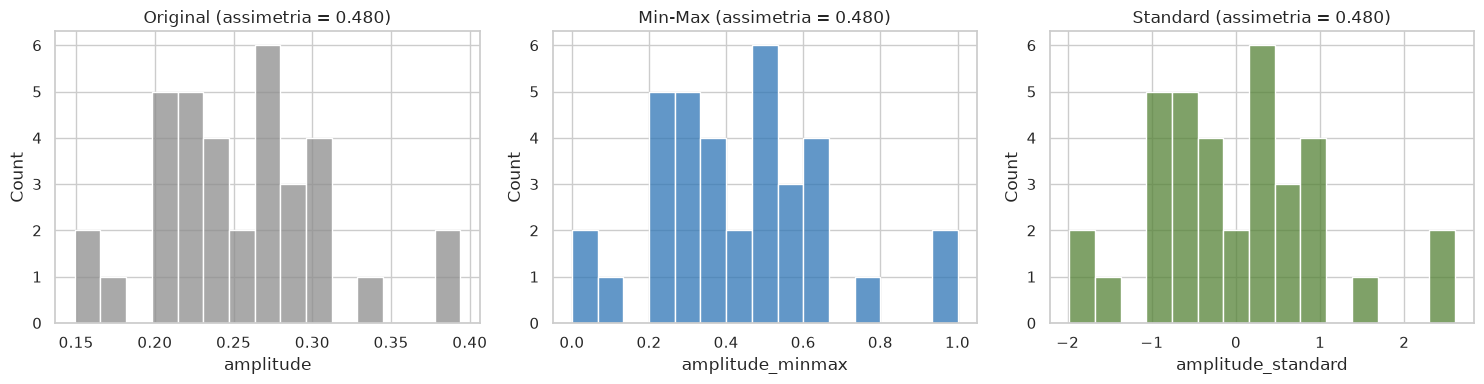

In [220]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(dataframe_escala["amplitude"], bins=15, ax=axes[0], color="#8C8C8C")
axes[0].set_title(f"Original (assimetria = {dataframe_escala['amplitude'].skew():.3f})")

sns.histplot(dataframe_minmax["amplitude_minmax"], bins=15, ax=axes[1], color="#2E75B6")
axes[1].set_title(f"Min-Max (assimetria = {dataframe_minmax['amplitude_minmax'].skew():.3f})")

sns.histplot(dataframe_standard["amplitude_standard"], bins=15, ax=axes[2], color="#548235")
axes[2].set_title(f"Standard (assimetria = {dataframe_standard['amplitude_standard'].skew():.3f})")

plt.tight_layout()
plt.show()

> 💡 **Observação importante:** note que a **forma** da distribuição (a assimetria) permanece a mesma nas três versões — o escalonamento muda apenas a escala dos valores, não a distribuição relativa dos dados. Por isso, variáveis assimétricas costumam ser primeiro transformadas (ex.: log, Módulo 14) e só depois escalonadas.

### 15.4 Normalização por amostra (SNV)

As seções anteriores escalonaram **features** — cada coluna de `resumo`. Existe uma segunda operação, necessária a dados espectrais: normalizar cada **amostra**.

In [221]:
scaler_espectros = StandardScaler()
espectros_snv = pd.DataFrame(
    scaler_espectros.fit_transform(dataframe_limpo[variaveis_numericas]),
    columns=variaveis_numericas,
    index=dataframe_limpo.index,
)

print("Verificação — M1_7 após SNV: média = %.6f | desvio = %.4f"
      % (espectros_snv["M1_7"].mean(), espectros_snv["M1_7"].std(ddof=0)))

Verificação — M1_7 após SNV: média = -0.000000 | desvio = 1.0000


In [222]:
comparacao_snv = pd.DataFrame({
    "amplitude_antes": dataframe_limpo[variaveis_numericas].max() - dataframe_limpo[variaveis_numericas].min(),
    "amplitude_depois": espectros_snv.max() - espectros_snv.min(),
})
comparacao_snv["zscore_antes"] = np.abs(stats.zscore(comparacao_snv["amplitude_antes"]))
comparacao_snv["zscore_depois"] = np.abs(stats.zscore(comparacao_snv["amplitude_depois"]))

print("--- Ordenado por z-score ANTES do SNV ---")
print(comparacao_snv.sort_values("zscore_antes", ascending=False).round(3).head().to_string())

print("\n--- Ordenado por z-score DEPOIS do SNV ---")
print(comparacao_snv.sort_values("zscore_depois", ascending=False).round(3).head().to_string())

for coluna in ["amplitude_antes", "amplitude_depois"]:
    Q1, Q3 = comparacao_snv[coluna].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    fora = comparacao_snv.index[(comparacao_snv[coluna] < Q1 - 1.5 * IQR) | (comparacao_snv[coluna] > Q3 + 1.5 * IQR)]
    acima_de_3 = comparacao_snv.index[comparacao_snv[coluna.replace("amplitude", "zscore")] > 3]
    print(f"\n{coluna}: IQR -> {list(fora)} | Z-score > 3 -> {list(acima_de_3)}")


--- Ordenado por z-score ANTES do SNV ---
       amplitude_antes  amplitude_depois  zscore_antes  zscore_depois
M1_7             0.394             4.310         2.599          0.780
PC_2             0.379             4.269         2.318          0.873
PC_7             0.149             4.871         1.983          0.457
M2_1             0.160             6.496         1.772          4.046
PC_12            0.337             4.634         1.534          0.065

--- Ordenado por z-score DEPOIS do SNV ---
       amplitude_antes  amplitude_depois  zscore_antes  zscore_depois
M2_1             0.160             6.496         1.772          4.046
M2_3             0.179             6.036         1.417          3.029
M2_10            0.238             5.373         0.310          1.565
PC_11            0.202             4.170         0.992          1.091
PC_1             0.300             4.230         0.849          0.957

amplitude_antes: IQR -> ['M1_7'] | Z-score > 3 -> []

amplitude_depois: I

Vemos aqui que `M1_7`, que já havia sido considerado um possível outlier, foi normalizado e corrigido, enquanto `M2_1`, `M2_3` e `M2_10` foram detectados pelo IQR por terem uma anomalia de forma, diferentemente de `M1_7`.

### 15.5 Regra de ouro: fit apenas no treino

Em um projeto real, o `fit` do scaler deve ser feito **apenas com os dados de treinamento**, e o `transform` aplicado depois aos dados de validação/teste — evitando vazamento de dados (*data leakage*).

In [223]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    dataframe_escala, resumo["grupo"],
    test_size=0.2, random_state=42, stratify=resumo["grupo"]
)

scaler_correto = StandardScaler()
scaler_correto.fit(X_treino)

X_treino_escalado = scaler_correto.transform(X_treino)
X_teste_escalado = scaler_correto.transform(X_teste)

print(f"Treino: {len(X_treino)} amostras | Teste: {len(X_teste)} amostras")
print("Média do treino (usada no scaler):", X_treino["amplitude"].mean().round(4))
print("Média do teste (NÃO usada):       ", X_teste["amplitude"].mean().round(4))

Treino: 28 amostras | Teste: 7 amostras
Média do treino (usada no scaler): 0.2579
Média do teste (NÃO usada):        0.2436


O princípio vale, mas a base tem um problema prático: `test_size=0.2` dá 28 amostras de treino e apenas 7 de teste — cerca de 2 por grupo. Um conjunto de teste desse tamanho não oferece avaliação confiável, e as amostras individuais deslocam a métrica em mais de 14%. Usar `stratify` é obrigatório aqui: sem ele, um sorteio desfavorável pode deixar um grupo inteiro fora do treino.

---
# 🎯 Módulo 16 — Seleção de Features

Vamos aplicar métodos de seleção de features para identificar quais variáveis são mais relevantes para prever o **grupo celular** (`grupo`) — saudável, carcinoma primário ou metastático.

### 16.1 Preparando a base para seleção de features

In [224]:
features_candidatas = [
    "media", "mediana", "desvio_padrao", "amplitude", "razao_amp_desvio",
    "media_faixa_400_900", "media_faixa_900_1800",
    "media_faixa_1800_2700", "media_faixa_2700_4000",
]
# amplitude_media_do_grupo e desvio_do_proprio_grupo ficam de fora:
# derivam do alvo (grupo) e causariam vazamento de alvo.

X = resumo[features_candidatas]
y = resumo["grupo"]

print(f"Formato de X: {X.shape} | classes: {dict(y.value_counts())}")
X.head()


Formato de X: (35, 9) | classes: {'M1': np.int64(12), 'PC': np.int64(12), 'M2': np.int64(11)}


,media,mediana,desvio_padrao,amplitude,razao_amp_desvio,media_faixa_400_900,media_faixa_900_1800,media_faixa_1800_2700,media_faixa_2700_4000
M1_1,0.008133,0.016711,0.043144,0.203098,4.707485,-0.039119,0.041054,0.020345,-0.004849
M1_2,0.030800,0.049690,0.060212,0.285324,4.738650,-0.047323,0.067282,0.057595,0.017188
M1_3,0.036991,0.057131,0.047622,0.225688,4.739195,-0.043103,0.060121,0.062611,0.034188
M1_4,0.008898,0.023393,0.047329,0.216401,4.572301,-0.041044,0.046479,0.025472,-0.009285
M1_5,0.030913,0.057035,0.062186,0.270445,4.348994,-0.040818,0.069096,0.063773,0.009437


### 16.2 Análise de correlação com a variável-alvo

In [225]:
for classe in ["PC", "M1", "M2"]:
    alvo_binario = (y == classe).astype(int)
    correlacao = X.assign(alvo=alvo_binario).corr()["alvo"].drop("alvo")
    print(f"\n--- Correlação com '{classe}' ---")
    print(correlacao.sort_values(key=abs, ascending=False).head(3).round(3))


--- Correlação com 'PC' ---
razao_amp_desvio      -0.299
media_faixa_400_900   -0.215
desvio_padrao          0.191
Name: alvo, dtype: float64

--- Correlação com 'M1' ---
razao_amp_desvio      -0.188
media_faixa_400_900   -0.157
mediana                0.096
Name: alvo, dtype: float64

--- Correlação com 'M2' ---
razao_amp_desvio       0.497
media_faixa_400_900    0.381
desvio_padrao         -0.282
Name: alvo, dtype: float64


### 16.3 Multicolinearidade entre features

Antes de selecionar, vamos identificar features redundantes entre si (alta correlação mútua).

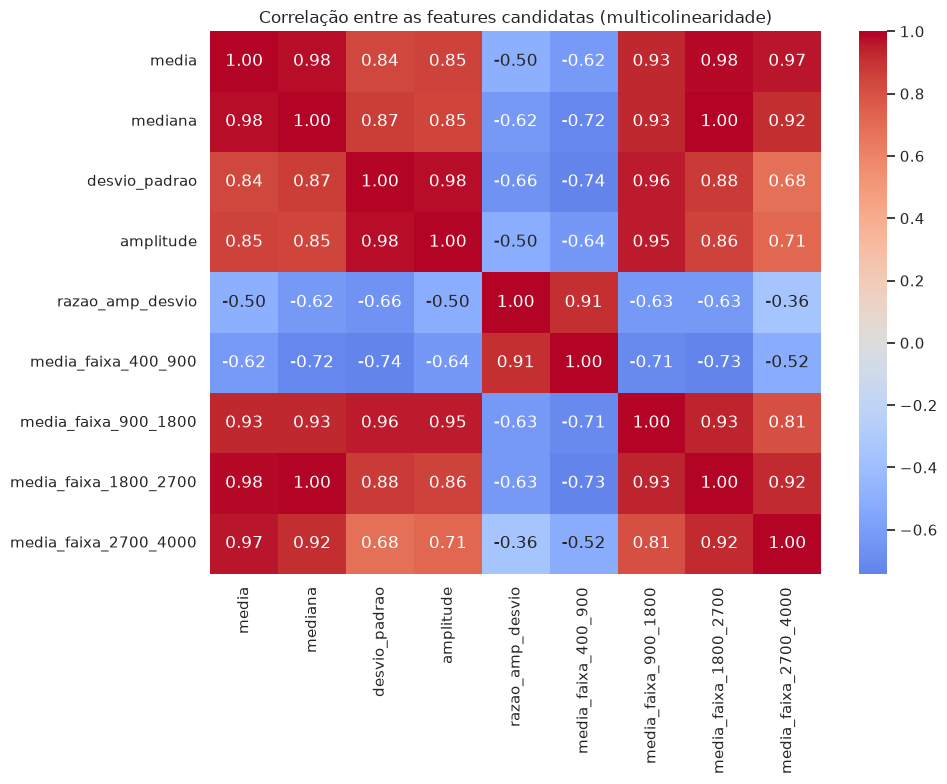

In [226]:
matriz_corr_features = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr_features, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlação entre as features candidatas (multicolinearidade)")
plt.tight_layout()
plt.show()

In [227]:
pares_redundantes = matriz_corr_features.unstack()
pares_redundantes = pares_redundantes[(pares_redundantes.abs() > 0.8) & (pares_redundantes.abs() < 1.0)]
pares_redundantes.drop_duplicates()

media                  mediana                  0.977639
                       desvio_padrao            0.839106
                       amplitude                0.851655
                       media_faixa_900_1800     0.927959
                       media_faixa_1800_2700    0.980250
                       media_faixa_2700_4000    0.965140
mediana                desvio_padrao            0.865770
                       amplitude                0.846388
                       media_faixa_900_1800     0.929513
                       media_faixa_1800_2700    0.996666
                       media_faixa_2700_4000    0.915765
desvio_padrao          amplitude                0.977810
                       media_faixa_900_1800     0.957934
                       media_faixa_1800_2700    0.877457
amplitude              media_faixa_900_1800     0.953126
                       media_faixa_1800_2700    0.856330
razao_amp_desvio       media_faixa_400_900      0.907685
media_faixa_900_1800   media_fa

> 💡 `razao_amp_desvio` foi construída a partir de `amplitude` e `desvio_padrao` (Módulo 14) — por isso apresenta correlação alta com ambas. As features de faixa espectral, por sua vez, correlacionam-se fortemente com `media`, o que era esperado: a média global do espectro é aproximadamente a média ponderada das faixas.
>
> Como visto no Módulo 12, a origem comum dessa redundância é a intensidade global da medição, que afeta todas as métricas na mesma direção. E como visto no Módulo 15, a normalização **não** resolve esse problema.


### 16.4 SelectKBest

In [228]:
selecionador = SelectKBest(score_func=f_classif, k=5)
selecionador.fit(X, y)

scores = pd.DataFrame({
    "F_score": selecionador.scores_,
    "p_valor": selecionador.pvalues_,
}, index=X.columns).sort_values("F_score", ascending=False)

print(scores.round(4))
print("\nSelecionadas:", list(X.columns[selecionador.get_support()]))
print("Com p < 0,05:", int((selecionador.pvalues_ < 0.05).sum()), "de", X.shape[1])

                       F_score  p_valor
razao_amp_desvio        5.3736   0.0097
media_faixa_400_900     2.7405   0.0797
desvio_padrao           1.4552   0.2484
media_faixa_900_1800    0.9923   0.3818
media_faixa_1800_2700   0.6319   0.5381
mediana                 0.5971   0.5564
amplitude               0.5282   0.5947
media                   0.3297   0.7215
media_faixa_2700_4000   0.1016   0.9037

Selecionadas: ['desvio_padrao', 'razao_amp_desvio', 'media_faixa_400_900', 'media_faixa_900_1800', 'media_faixa_1800_2700']
Com p < 0,05: 1 de 9


### 16.5 RFE (Recursive Feature Elimination)

In [229]:
X_padronizado = StandardScaler().fit_transform(X)

rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=5)
rfe.fit(X_padronizado, y)

print("Features selecionadas pelo RFE:", list(X.columns[rfe.support_]))

Features selecionadas pelo RFE: ['mediana', 'desvio_padrao', 'razao_amp_desvio', 'media_faixa_1800_2700', 'media_faixa_2700_4000']


### 16.6 Importância de features via Random Forest

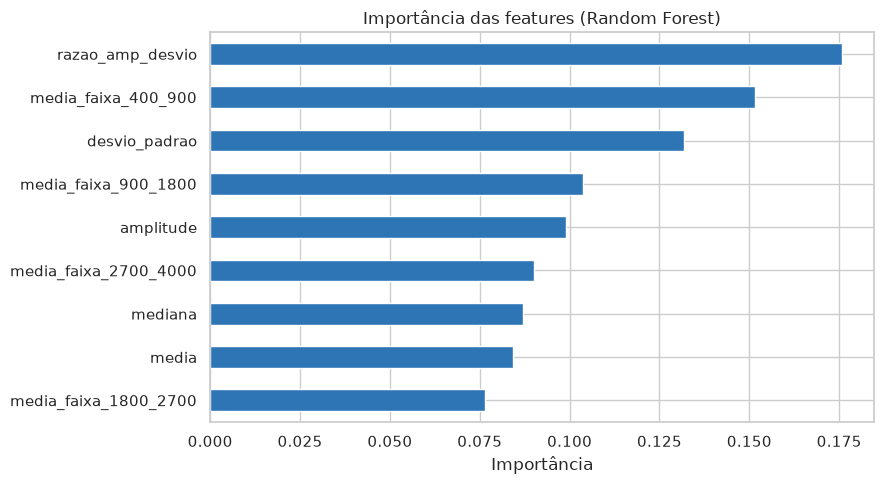

In [230]:
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_rf.fit(X, y)

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importancias.plot(kind="barh", color="#2E75B6")
plt.title("Importância das features (Random Forest)")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 16.7 Validação

In [231]:
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.pipeline import make_pipeline

modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

acuracia_todas = cross_val_score(modelo, X, y, cv=LeaveOneOut()).mean()
acuracia_melhor = cross_val_score(modelo, X[["razao_amp_desvio"]], y, cv=LeaveOneOut()).mean()
baseline = y.value_counts().max() / len(y)

print(f"Acurácia LOO — 9 features:            {acuracia_todas:.3f}")
print(f"Acurácia LOO — só razao_amp_desvio:   {acuracia_melhor:.3f}")
print(f"Baseline (chutar sempre a classe majoritária): {baseline:.3f}")

Acurácia LOO — 9 features:            0.143
Acurácia LOO — só razao_amp_desvio:   0.314
Baseline (chutar sempre a classe majoritária): 0.343


In [232]:
features_com_vazamento = features_candidatas + ["desvio_do_proprio_grupo", "amplitude_media_do_grupo"]
acuracia_vazamento = cross_val_score(modelo, resumo[features_com_vazamento], y, cv=LeaveOneOut()).mean()
print(f"Acurácia LOO INCLUINDO as features vazadas: {acuracia_vazamento:.3f}")

Acurácia LOO INCLUINDO as features vazadas: 0.857


> 💡 **Conclusão do módulo:** Entre as nove features candidatas, apenas `razao_amp_desvio` alcança significância estatística (p = 0,0097), e os três métodos — SelectKBest, RFE e Random Forest — convergem nela. O resultado valida a engenharia de features do Módulo 14: a única variável com poder discriminante não existia nos dados originais, foi construída.
>
> A validação leave-one-out, porém, mostra que isso não é suficiente. Nenhuma configuração supera o baseline de 34,3% (a proporção da classe majoritária): com as nove features a acurácia cai a **14,3%**, evidência de sobreajuste — nove parâmetros ajustados a 35 amostras —, e com a melhor feature isolada alcança **31,4%**.
>
> Incluir as features derivadas do próprio alvo eleva a acurácia a **85,7%**, um valor que pareceria excelente em um relatório e é inteiramente artificial. É a demonstração prática de por que `amplitude_media_do_grupo` e `desvio_do_proprio_grupo` foram excluídas em 16.1: o vazamento de alvo não gera erro nem aviso, apenas resultados bons demais.
>
> A conclusão é, portanto, metodológica: as técnicas foram aplicadas corretamente e identificaram a variável mais promissora, mas a base — 35 amostras para 3 classes, sem pré-processamento espectral avançado — não sustenta um classificador. O estudo original obtém discriminação porque combina derivadas espectrais, faixas otimizadas e validação em conjunto independente, etapas além do escopo destes módulos.
>
> Reforça-se, assim, a ideia central do módulo: **mais features não significa um modelo melhor** — e, neste caso, significa um modelo pior.


---
# ⚠️ Módulo 17 — Dados Desbalanceados

Diferentemente do dataset de imóveis, esta base é **praticamente balanceada**: 12 amostras de células saudáveis, 12 de carcinoma primário e 11 metastáticas. O módulo, portanto, se aplica pelo caminho inverso — em vez de tratar o desbalanceamento, verificamos sua ausência e examinamos o que isso muda na avaliação do modelo construído no Módulo 16.


### 17.1 Identificando o desbalanceamento

In [233]:
contagem_grupos = resumo["grupo"].value_counts()
proporcao_grupos = resumo["grupo"].value_counts(normalize=True) * 100

print(contagem_grupos)
print("\nProporção (%):")
print(proporcao_grupos.round(2))
print(f"\nRazão entre a maior e a menor classe: {contagem_grupos.max() / contagem_grupos.min():.2f}")

grupo
M1    12
PC    12
M2    11
Name: count, dtype: int64

Proporção (%):
grupo
M1    34.29
PC    34.29
M2    31.43
Name: proportion, dtype: float64

Razão entre a maior e a menor classe: 1.09


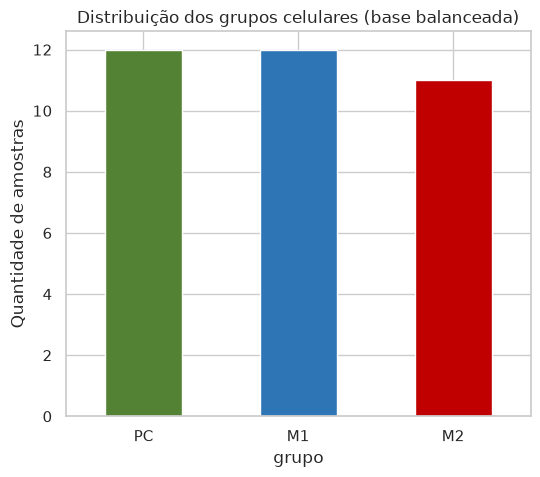

In [234]:
plt.figure(figsize=(6, 5))
contagem_grupos.reindex(["PC", "M1", "M2"]).plot(kind="bar", color=["#548235", "#2E75B6", "#C00000"])
plt.title("Distribuição dos grupos celulares (base balanceada)")
plt.ylabel("Quantidade de amostras")
plt.xticks(rotation=0)
plt.show()

> 💡 A base é praticamente equilibrada: razão de **1,09** entre a maior e a menor classe. Compare com o exemplo do material original, em que 6 registros de uma classe se opõem a 1.453 da outra (~99,6% vs. ~0,4%) — razão de 242.
>
> Esse equilíbrio não é acidental: o conjunto foi montado para o estudo com número aproximadamente igual de amostras por grupo. Nenhuma técnica de balanceamento é necessária aqui.


### 17.2 Por que a acurácia pode enganar

Com classes desbalanceadas, um classificador que sempre prevê a classe majoritária alcança acurácia altíssima — 99,59% no exemplo do material — e essa métrica esconde a inutilidade do modelo.

Aqui ocorre o oposto. Como as classes são equilibradas, o classificador ingênuo alcança apenas **34,29%**, um patamar honesto: com três classes de tamanho semelhante, qualquer modelo útil precisa superá-lo.

O resultado é revelador. O modelo construído no Módulo 16 alcançou **14,3%** na validação leave-one-out — menos da metade do classificador ingênuo, e menos da metade do que se obteria por sorteio aleatório entre três classes (~33%). Em uma base balanceada, a acurácia não engana: ela expõe o fracasso do modelo em vez de mascará-lo.

A lição do módulo se mantém, portanto, com o sinal trocado: **a acurácia só é interpretável em relação à distribuição das classes**. Sem conhecer o baseline, 34% pareceria ruim e 99% pareceria ótimo — e ambas as leituras estariam erradas.

In [235]:
acuracia_ingenua = (resumo["grupo"] == "PC").mean()
print(f"Acurácia de um modelo que sempre prevê 'PC': {acuracia_ingenua:.4f} ({acuracia_ingenua*100:.2f}%)")
print(f"Acurácia do modelo do Módulo 16 (leave-one-out): 0.143 (14.30%)")

Acurácia de um modelo que sempre prevê 'PC': 0.3429 (34.29%)
Acurácia do modelo do Módulo 16 (leave-one-out): 0.143 (14.30%)


### 17.3 Simulando undersampling e oversampling

As técnicas não são necessárias nesta base, mas existe um cenário concreto em que passariam a ser: a remoção das amostras sinalizadas no controle de qualidade do Módulo 7.

In [236]:
resumo_qc = resumo.drop(["M2_1"])
print("Após remover M2_1:")
print(resumo_qc["grupo"].value_counts())

grupos_separados = {g: resumo_qc[resumo_qc["grupo"] == g] for g in ["PC", "M1", "M2"]}
print("\nRazão entre maior e menor classe:",
      round(max(len(d) for d in grupos_separados.values()) / min(len(d) for d in grupos_separados.values()), 2))

Após remover M2_1:
grupo
M1    12
PC    12
M2    10
Name: count, dtype: int64

Razão entre maior e menor classe: 1.2


In [237]:
tamanho_menor = min(len(d) for d in grupos_separados.values())
resumo_undersampled = pd.concat([d.sample(n=tamanho_menor, random_state=42) for d in grupos_separados.values()])

print("Distribuição após undersampling:")
print(resumo_undersampled["grupo"].value_counts())

Distribuição após undersampling:
grupo
PC    10
M1    10
M2    10
Name: count, dtype: int64


In [238]:
tamanho_maior = max(len(d) for d in grupos_separados.values())
resumo_oversampled = pd.concat([d.sample(n=tamanho_maior, replace=True, random_state=42) for d in grupos_separados.values()])

print("Distribuição após oversampling:")
print(resumo_oversampled["grupo"].value_counts())

Distribuição após oversampling:
grupo
PC    12
M1    12
M2    12
Name: count, dtype: int64


> 💡 Removendo `M2_1`, a base passa a 12/12/10 (razão 1,20); removendo também `M2_3`, a 12/12/9 (razão 1,33). Ainda são desequilíbrios modestos, mas ilustram o problema: **o controle de qualidade e o balanceamento são objetivos em tensão** — descartar amostras defeituosas melhora a qualidade dos dados e piora a simetria entre classes.
>
> Vale notar que o estudo original resolveu exatamente esse conflito por undersampling: removeu `M1_8` e `PC_5` no QC por PCA e, para restaurar a simetria, trabalhou com **11 amostras por grupo** (33 no total, dos 35 disponíveis).
>
> Com 9 a 12 amostras por classe, porém, o undersampling é caro: cada amostra descartada representa cerca de 10% da classe. Em bases desse tamanho, a alternativa preferível é manter todas as amostras e compensar o desequilíbrio no próprio modelo, com o parâmetro `class_weight="balanced"` dos classificadores do scikit-learn.

### 17.4 SMOTE (conceitual)

O SMOTE gera exemplos **sintéticos** da classe minoritária, interpolando entre observações existentes (em vez de apenas duplicá-las, como no oversampling simples). Sua implementação prática requer a biblioteca `imbalanced-learn`:

```python
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)
X_resampled, y_resampled = smote.fit_resample(X, y)
```

> ⚠️ O SMOTE é inadequado nesta base por dois motivos. Primeiro, o desbalanceamento é irrelevante (razão 1,09) — não há o que corrigir. Segundo, e mais importante: o SMOTE interpola entre vizinhos no espaço de features, e com 3.736 dimensões e 11 amostras por classe, cada ponto está isolado (o problema conhecido como *maldição da dimensionalidade*). As amostras sintéticas seriam médias de espectros distantes entre si, sem correspondência com nenhuma célula real.
>
> Aplicado aos espectros completos, o SMOTE geraria dados que parecem plausíveis e não são — um risco maior que o problema que se propõe a resolver.

### 17.5 Métricas apropriadas para dados desbalanceados

Em vez de depender apenas da acurácia, deve-se avaliar o modelo com métricas como **precisão**, **revocação (recall)**, **F1-score** e **AUC-ROC**, que consideram o desempenho especificamente na classe minoritária.

In [239]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

previsoes = cross_val_predict(modelo, X, y, cv=LeaveOneOut())

print(classification_report(y, previsoes, zero_division=0))

print("Matriz de confusão (linhas = real, colunas = previsto):")
print(pd.DataFrame(
    confusion_matrix(y, previsoes, labels=["PC", "M1", "M2"]),
    index=["PC (real)", "M1 (real)", "M2 (real)"],
    columns=["PC (prev)", "M1 (prev)", "M2 (prev)"],
))

              precision    recall  f1-score   support

          M1       0.06      0.08      0.07        12
          M2       0.33      0.27      0.30        11
          PC       0.11      0.08      0.10        12

    accuracy                           0.14        35
   macro avg       0.17      0.15      0.15        35
weighted avg       0.16      0.14      0.15        35

Matriz de confusão (linhas = real, colunas = previsto):
           PC (prev)  M1 (prev)  M2 (prev)
PC (real)          1          9          2
M1 (real)          7          1          4
M2 (real)          1          7          3


> 💡 **Observação final:** o `classification_report` mostra o que a acurácia global de 14% resume: apenas 5 das 35 amostras foram classificadas corretamente (a diagonal da matriz: 1 + 1 + 3).
>
> A matriz de confusão revela um padrão sistemático, não aleatório: das 12 amostras `PC` reais, **9 foram classificadas como `M1`**; das 12 `M1` reais, 7 foram para `PC`. O modelo confunde justamente os dois grupos que, desde o Módulo 12, se mostraram indistinguíveis (`M1`↔`PC` = 0,9711, praticamente igual a `PC`↔`PC` = 0,9702).
>
> `M2` é a única classe com desempenho acima do trivial (F1 = 0,30) — coerente com o Módulo 16, em que `razao_amp_desvio`, única feature significativa, distingue `M2` por causa de `M2_1`, `M2_3` e `M2_10`.
>
> Desempenho **abaixo** do aleatório indica que o modelo não apenas falhou em aprender: ele aprendeu relações do conjunto de treino que se invertem no de teste — a assinatura clássica do sobreajuste quando o número de features se aproxima do número de amostras.
>
> Este é o valor das métricas por classe. A acurácia diria apenas "14%"; o relatório completo mostra *quais* classes o modelo confunde e *por quê* — informação que conecta o resultado às conclusões dos Módulos 12 e 16.

---
# ✅ Conclusão

Neste notebook, percorremos na prática os Módulos 2 a 17 da apostila *Engenharia e Preparação de Dados*, aplicando cada técnica ao dataset de espectros ATR-FTIR de células cervicais (`all_spectra_combined.csv`):

- Carregamos e exploramos os dados brutos (Módulo 2) e diagnosticamos sua qualidade (Módulo 3), constatando ausência de valores nulos, duplicatas e tipos incorretos — o que tornou o Módulo 4 majoritariamente dispensável;
- Analisamos as variáveis numéricas (Módulo 6) construindo a tabela `resumo`, que transpôs a unidade de análise de 3.736 números de onda para 35 amostras;
- Detectamos outliers (Módulo 7) e aprofundamos a análise estatística (Módulo 8), identificando `M1_7` por intensidade e `M2_1`/`M2_3` por forma;
- Visualizamos distribuições (Módulo 9) e aplicamos probabilidade (Módulos 10 e 11), constatando independência entre as métricas e o grupo celular;
- Investigamos correlações (Módulo 12) e construímos visualizações diversas (Módulo 13), incluindo o gráfico espectral;
- Criamos novas features (Módulo 14) e as normalizamos (Módulo 15), onde o SNV corrigiu `M1_7` e revelou `M2_1` e `M2_3`;
- Selecionamos as features mais relevantes (Módulo 16) e verificamos o balanceamento das classes (Módulo 17).

## Principais conclusões sobre esta base

**O tratamento de dados foi bem-sucedido.** A base não apresentava valores ausentes nem inconsistências de tipo. O controle de qualidade identificou três amostras problemáticas por métodos independentes e convergentes (IQR, Z-score, correlação entre amostras e normalização SNV), distinguindo corretamente entre desvio de **intensidade** — corrigível por normalização — e desvio de **forma**, que não é.

**A classificação não foi bem-sucedida, e isso é o resultado.** Cinco análises independentes convergiram: as métricas resumidas do espectro não distinguem os grupos celulares. A sobreposição das distribuições (Módulo 9), a independência probabilística (Módulo 10), a ausência de associação na tabela de contingência (Módulo 11), a igualdade entre correlação intra e intergrupo (0,9238 vs. 0,9231, Módulo 12) e a acurácia de 14,3% contra um baseline de 34,3% (Módulos 16 e 17) apontam na mesma direção.

**As limitações são de tamanho de amostra, não de método.** Com 35 amostras e 3.736 features, o critério de Z-score > 3 é praticamente inatingível (prevê 0,09 ocorrências), as probabilidades têm resolução de 1/35, as tabelas de contingência violam as frequências mínimas esperadas, e a seleção univariada captura artefatos — nenhum wavenumber mantém significância após a remoção de duas amostras anômalas.

> 🎯 **Próximos passos.** O estudo de origem obtém discriminação entre os grupos, o que confirma que a informação existe na base. As etapas que faltam, além do escopo destes módulos, são: correção de linha de base e derivadas espectrais (Savitzky-Golay), análise multivariada (PCA, PLS-DA) em lugar de métricas univariadas, e validação em conjunto independente. A faixa de **718 a 722 cm⁻¹**, identificada por inspeção visual (Módulo 13) e confirmada no topo do ranking de F-scores (Módulo 16) mesmo após a remoção das amostras anômalas, é a candidata mais promissora para essa investigação.

In [241]:
resumo.to_csv("./data/dados_tratados.csv", index=False)

print("Arquivo 'dados_tratados.csv' criado com sucesso!")

Arquivo 'dados_tratados.csv' criado com sucesso!
